In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!git clone https://github.com/CosmiQ/CosmiQ_SN7_Baseline.git
%cd CosmiQ_SN7_Baseline

Cloning into 'CosmiQ_SN7_Baseline'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 47 (delta 2), reused 5 (delta 2), pack-reused 35 (from 1)
Receiving objects: 100% (47/47), 194.02 MiB | 23.09 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (21/21), done.
/content/CosmiQ_SN7_Baseline


In [3]:
!ls


docker	docs  LICENSE  models  notebooks  README.md  src  yml


In [4]:
!find models -maxdepth 3 -type f | head -50

models/sn7_baseline/README.txt
models/sn7_baseline/weight_split/ab
models/sn7_baseline/weight_split/aa


In [5]:
!cat models/sn7_baseline/README.txt

# split weight file
mkdir weight_split
split -b 80m xdxd_final.pth weight_split/
# re-combine weight file
cat weight_split/* > xdxd_final.pth

In [6]:
!find models/sn7_baseline/weight_split -type f -exec ls -lh {} \;

-rw-r--r-- 1 root root 32M Sep 19 13:42 models/sn7_baseline/weight_split/ab
-rw-r--r-- 1 root root 80M Sep 19 13:42 models/sn7_baseline/weight_split/aa


In [7]:
!find notebooks -maxdepth 2 -type f | sort

notebooks/__init__.py
notebooks/sn7_baseline.ipynb
notebooks/sn7_data_prep.ipynb


In [8]:
!nvidia-smi


Sat Sep 19 13:47:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
!cat models/sn7_baseline/README.txt

# split weight file
mkdir weight_split
split -b 80m xdxd_final.pth weight_split/
# re-combine weight file
cat weight_split/* > xdxd_final.pth

In [10]:
cat weight_split/* > xdxd_final.pth

cat: 'weight_split/*': No such file or directory


In [11]:
import json

with open("notebooks/sn7_baseline.ipynb", "r") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        code = "".join(cell["source"])
        if any(k in code.lower() for k in [
            "weight", "model", "infer", "predict", "checkpoint", "pth"
        ]):
            print(f"\n{'='*80}")
            print(f"CELL {i}")
            print(f"{'='*80}")
            print(code[:5000])


CELL 4
# Set prediction and image directories (edit appropriately)
pred_top_dir = '/path_to_baseline/inference_out/sn7_baseline_preds'
im_top_dir = '/local_data/sn7/aws_download/test_public'

from shapely.ops import cascaded_union
import matplotlib.pyplot as plt
import geopandas as gpd
import multiprocessing
import pandas as pd
import numpy as np
import skimage.io
import tqdm
import glob
import math
import gdal
import time
import sys
import os

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
import matplotlib
# matplotlib.use('Agg') # non-interactive

import solaris as sol
from solaris.utils.core import _check_gdf_load
from solaris.raster.image import create_multiband_geotiff 

# import from data_postproc_funcs
module_path = os.path.abspath(os.path.join('../src/'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sn7_baseline_postproc_funcs import map_wrapper, multithread_polys, \
   

In [12]:
!find src -type f | sort

src/__init__.py
src/sn7_baseline_infer.py
src/sn7_baseline_postproc_funcs.py
src/sn7_baseline_prep_funcs.py
src/sn7_baseline_train.py


In [13]:
!grep -RniE "xdxd_final|weight_split|load_state|torch.load|checkpoint|predict" src models notebooks | head -100

src/sn7_baseline_postproc_funcs.py:54:    """Get the best intersection over union for a predicted polygon.
src/sn7_baseline_postproc_funcs.py:61:        Prediction polygon to test.
models/sn7_baseline/README.txt:2:mkdir weight_split
models/sn7_baseline/README.txt:3:split -b 80m xdxd_final.pth weight_split/
models/sn7_baseline/README.txt:5:cat weight_split/* > xdxd_final.pth
notebooks/sn7_baseline.ipynb:59:    "The `sn7_baseline_infer.py` script executes the segmentation model, which is only the first step in the extracting matched building footprints in the data cube.  In the cells below, we refine these predictioms masks to the final output."
notebooks/sn7_baseline.ipynb:68:    "# Set prediction and image directories (edit appropriately)\n",
notebooks/sn7_baseline.ipynb:112:    "### 3.A. Group predictions by AOI"
notebooks/sn7_baseline.ipynb:142:    "## 3.B. (Optional) Explore predictions"
notebooks/sn7_baseline.ipynb:220:    "ax1.set_title('Prediction Mask')\n",
notebooks/sn7_baselin

In [14]:
%cd /content/CosmiQ_SN7_Baseline/models/sn7_baseline

!cat weight_split/aa weight_split/ab > xdxd_final.pth

!ls -lh xdxd_final.pth

/content/CosmiQ_SN7_Baseline/models/sn7_baseline
-rw-r--r-- 1 root root 112M Sep 19 13:51 xdxd_final.pth


In [15]:
import os

path = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

print("Exists:", os.path.exists(path))
print("Size:", os.path.getsize(path) / (1024**2), "MB")

Exists: True
Size: 111.80980205535889 MB


In [16]:
%cd /content/CosmiQ_SN7_Baseline

/content/CosmiQ_SN7_Baseline


In [17]:
!cat yml/sn7_baseline_infer.yml

model_name: xdxd_spacenet4

model_path: '/path_to_baseline/models/sn7_baseline/xdxd_final.pth'
train: false
infer: true

pretrained: true
nn_framework: torch
batch_size: 6

data_specs:
  width: 512
  height: 512
  dtype:
  image_type: zscore
  rescale: false
  rescale_minima: auto
  rescale_maxima: auto
  channels: 4
  label_type: mask
  is_categorical: false
  mask_channels: 1
  val_holdout_frac: 0.1
  data_workers:

training_data_csv:
validation_data_csv:
inference_data_csv: '/local_data/sn7/aws_download/csvs/sn7_baseline_test_public_df.csv'

training_augmentation:
  augmentations:
    DropChannel:
      idx: 3
      axis: 2
    HorizontalFlip:
      p: 0.5
    RandomRotate90:
      p: 0.5
    RandomCrop:
      height: 512
      width: 512
      p: 1.0
  p: 1.0
  shuffle: true
validation_augmentation:
  augmentations:
    DropChannel:
      idx: 3
      axis: 2
    CenterCrop:
      height: 512
      width: 512
      p: 1.0
  p: 1.0
inference_augmentation:
  augmentations:
    DropCh

In [18]:
!cp yml/sn7_baseline_infer.yml yml/gt_colab_infer.yml

In [19]:
from pathlib import Path

cfg = Path("yml/gt_colab_infer.yml")

text = cfg.read_text()

text = text.replace(
    "/path_to_baseline/models/sn7_baseline/xdxd_final.pth",
    "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"
)

text = text.replace(
    "/path_to_baseline/inference_out/sn7_baseline_preds/raw",
    "/content/CosmiQ_SN7_Baseline/inference_out/sn7_baseline_preds/raw"
)

cfg.write_text(text)

print(cfg.read_text())

model_name: xdxd_spacenet4

model_path: '/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth'
train: false
infer: true

pretrained: true
nn_framework: torch
batch_size: 6

data_specs:
  width: 512
  height: 512
  dtype:
  image_type: zscore
  rescale: false
  rescale_minima: auto
  rescale_maxima: auto
  channels: 4
  label_type: mask
  is_categorical: false
  mask_channels: 1
  val_holdout_frac: 0.1
  data_workers:

training_data_csv:
validation_data_csv:
inference_data_csv: '/local_data/sn7/aws_download/csvs/sn7_baseline_test_public_df.csv'

training_augmentation:
  augmentations:
    DropChannel:
      idx: 3
      axis: 2
    HorizontalFlip:
      p: 0.5
    RandomRotate90:
      p: 0.5
    RandomCrop:
      height: 512
      width: 512
      p: 1.0
  p: 1.0
  shuffle: true
validation_augmentation:
  augmentations:
    DropChannel:
      idx: 3
      axis: 2
    CenterCrop:
      height: 512
      width: 512
      p: 1.0
  p: 1.0
inference_augmentation:
  augmentations:

In [20]:
import sys
print(sys.version)

try:
    import solaris
    print("Solaris:", solaris.__version__)
except Exception as e:
    print("Solaris import error:")
    print(type(e).__name__, e)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Solaris import error:
ModuleNotFoundError No module named 'solaris'


In [21]:
import sys

print("Python:", sys.version)

packages = [
    "torch",
    "tensorflow",
    "numpy",
    "rasterio",
    "geopandas",
    "shapely",
    "osgeo",
    "albumentations"
]

for pkg in packages:
    try:
        module = __import__(pkg)
        version = getattr(module, "__version__", "installed")
        print(f"{pkg:20s} ✅ {version}")
    except Exception as e:
        print(f"{pkg:20s} ❌ {type(e).__name__}: {e}")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
torch                ✅ 2.11.0+cu128
tensorflow           ✅ 2.20.0
numpy                ✅ 2.1.3
rasterio             ✅ 1.5.1
geopandas            ✅ 1.1.4
shapely              ✅ 2.1.2
osgeo                ✅ 3.8.4
albumentations       ✅ 2.0.8


In [22]:
!pip install --no-deps solaris==0.4.0

Requested solaris==0.4.0 from https://files.pythonhosted.org/packages/86/16/d6bd1d5a09c9a8c565227659817030b636be743d1487b41b069b0f1793fd/solaris-0.4.0-py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    gdal (>=3.0.2geopandas>=0.7.0)
         ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement solaris==0.4.0 (from versions: 0.0.1, 0.0.2, 0.0.3, 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.2.0, 0.2.1, 0.2.2, 0.3.0, 0.4.0)
ERROR: No matching distribution found for solaris==0.4.0


In [23]:
!python -m pip install "pip<24.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [24]:
!pip --version

pip 24.0 from /usr/local/lib/python3.13/dist-packages/pip (python 3.13)


In [25]:
!pip install --no-deps solaris==0.4.0

  Using cached solaris-0.4.0-py3-none-any.whl.metadata (1.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 10.4 MB/s eta 0:00:00


In [26]:
import solaris
print("Solaris version:", solaris.__version__)

ModuleNotFoundError: No module named 'gdal'

In [27]:
import solaris

print("Solaris imported successfully")
print("Solaris version:", getattr(solaris, "__version__", "version attribute unavailable"))
print("Solaris path:", solaris.__file__)

ModuleNotFoundError: No module named 'gdal'

In [28]:
import gdal

ModuleNotFoundError: No module named 'gdal'

In [29]:
import sys

# Modern GDAL bindings
from osgeo import gdal, gdalconst, ogr, osr

# Also provide the old gdalnumeric name if Solaris needs it
try:
    from osgeo import gdal_array
    gdalnumeric = gdal_array
except ImportError:
    gdalnumeric = None

# Compatibility aliases for old Solaris code
sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

if gdalnumeric is not None:
    sys.modules["gdalnumeric"] = gdalnumeric

print("✅ GDAL compatibility bridge installed")
print("GDAL version:", gdal.VersionInfo())

✅ GDAL compatibility bridge installed
GDAL version: 3080400


In [30]:
import solaris

print("✅ Solaris imported successfully")
print("Solaris path:", solaris.__file__)
print("Solaris version:", getattr(solaris, "__version__", "unknown"))

AttributeError: module 'keras._tf_keras.keras.metrics' has no attribute 'cosine_proximity'

In [31]:
import tensorflow as tf
from tensorflow import keras

legacy_names = [
    "binary_accuracy",
    "categorical_accuracy",
    "cosine_proximity",
    "hinge",
    "squared_hinge",
    "kullback_leibler_divergence",
    "mean_absolute_error",
    "mean_squared_error",
    "mean_squared_logarithmic_error",
    "sparse_categorical_accuracy",
    "top_k_categorical_accuracy",
]

print("TensorFlow:", tf.__version__)

for name in legacy_names:
    print(f"{name:35s}", "✅" if hasattr(keras.metrics, name) else "❌")

TensorFlow: 2.20.0
binary_accuracy                     ✅
categorical_accuracy                ✅
cosine_proximity                    ❌
hinge                               ✅
squared_hinge                       ✅
kullback_leibler_divergence         ✅
mean_absolute_error                 ❌
mean_squared_error                  ❌
mean_squared_logarithmic_error      ❌
sparse_categorical_accuracy         ✅
top_k_categorical_accuracy          ✅


In [32]:
import tensorflow as tf
from tensorflow import keras

# -------------------------------
# Solaris 0.4.0 / Keras 3 bridge
# -------------------------------

def cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )


def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )


def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.maximum(y_true, 0.0)
    y_pred = tf.maximum(y_pred, 0.0)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(y_true) -
            tf.math.log1p(y_pred)
        ),
        axis=-1
    )


# Add missing legacy names
legacy_metrics = {
    "cosine_proximity": cosine_proximity,
    "mean_absolute_error": mean_absolute_error,
    "mean_squared_error": mean_squared_error,
    "mean_squared_logarithmic_error": mean_squared_logarithmic_error,
}

for name, fn in legacy_metrics.items():
    if not hasattr(keras.metrics, name):
        setattr(keras.metrics, name, fn)

print("✅ Keras compatibility patch applied")

for name in legacy_metrics:
    print(f"{name:35s} ->", hasattr(keras.metrics, name))

✅ Keras compatibility patch applied
cosine_proximity                    -> True
mean_absolute_error                 -> True
mean_squared_error                  -> True
mean_squared_logarithmic_error      -> True


In [33]:
import solaris

print("✅ Solaris imported successfully")
print("Solaris path:", solaris.__file__)
print("Solaris version:", getattr(solaris, "__version__", "unknown"))

ImportError: cannot import name 'functional' from 'albumentations.augmentations' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/__init__.py)

In [34]:
from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim

ImportError: cannot import name 'functional' from 'albumentations.augmentations' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/__init__.py)

In [35]:
albumentations.augmentations.functional

NameError: name 'albumentations' is not defined

In [36]:
import sys
import importlib.metadata as md

print("Python:", sys.version)

try:
    import albumentations
    print("Albumentations version:", albumentations.__version__)
    print("Albumentations path:", albumentations.__file__)
except Exception as e:
    print("Albumentations import error:", repr(e))

print("Metadata version:", md.version("albumentations"))

!pip show albumentations

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Albumentations version: 2.0.8
Albumentations path: /usr/local/lib/python3.13/dist-packages/albumentations/__init__.py
Metadata version: 2.0.8
Name: albumentations
Version: 2.0.8
Summary: Fast, flexible, and advanced augmentation library for deep learning, computer vision, and medical imaging. Albumentations offers a wide range of transformations for both 2D (images, masks, bboxes, keypoints) and 3D (volumes, volumetric masks, keypoints) data, with optimized performance and seamless integration into ML workflows.
Home-page: 
Author: Vladimir Iglovikov
Author-email: 
License: MIT License

Copyright (c) 2017 Vladimir Iglovikov, Alexander Buslaev, Alexander Parinov,

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish,

In [37]:
!pip install --no-deps --force-reinstall albumentations==1.3.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


In [1]:
# Keep an older pip that accepts Solaris 0.4.0 metadata
!python -m pip install -q "pip<24.1"

# Install the old packages Solaris expects WITHOUT changing Colab's other dependencies
!pip install -q --no-deps solaris==0.4.0 albumentations==1.3.1

print("✅ Package installation complete")

DEPRECATION: solaris 0.4.0 has a non-standard dependency specifier gdal>=3.0.2geopandas>=0.7.0. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of solaris or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
✅ Package installation complete


In [2]:
import albumentations
import sys

print("Python:", sys.version)
print("Albumentations:", albumentations.__version__)

ModuleNotFoundError: No module named 'qudida'

In [3]:
import albumentations
import sys

print("Python:", sys.version)
print("Albumentations:", albumentations.__version__)
print("Path:", albumentations.__file__)

ModuleNotFoundError: No module named 'qudida'

In [4]:
!pip install -q --no-deps qudida

In [5]:
import albumentations

print("Albumentations:", albumentations.__version__)
print("Path:", albumentations.__file__)

Albumentations: 1.3.1
Path: /usr/local/lib/python3.13/dist-packages/albumentations/__init__.py


In [6]:
from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim

print("✅ Old Albumentations API works")

✅ Old Albumentations API works


In [7]:
import sys
from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

try:
    from osgeo import gdal_array
    sys.modules["gdalnumeric"] = gdal_array
except ImportError:
    pass

print("✅ GDAL bridge ready")

✅ GDAL bridge ready


In [8]:
import solaris

print("✅ Solaris imported")
print("Solaris:", getattr(solaris, "__version__", "unknown"))

AttributeError: module 'keras._tf_keras.keras.metrics' has no attribute 'cosine_proximity'

In [9]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

# ---- Compatibility for old Solaris/Keras API ----

def cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )


def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )


def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.maximum(tf.cast(y_true, tf.float32), 0.0)
    y_pred = tf.maximum(tf.cast(y_pred, tf.float32), 0.0)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(y_true) - tf.math.log1p(y_pred)
        ),
        axis=-1
    )


# Add the legacy names Solaris expects
keras.metrics.cosine_proximity = cosine_proximity
keras.metrics.mean_absolute_error = mean_absolute_error
keras.metrics.mean_squared_error = mean_squared_error
keras.metrics.mean_squared_logarithmic_error = mean_squared_logarithmic_error

print("✅ Legacy Keras metrics patched")

# Verify BEFORE importing Solaris
for name in [
    "cosine_proximity",
    "mean_absolute_error",
    "mean_squared_error",
    "mean_squared_logarithmic_error",
]:
    print(name, "->", hasattr(keras.metrics, name))

TensorFlow: 2.20.0
✅ Legacy Keras metrics patched
cosine_proximity -> True
mean_absolute_error -> True
mean_squared_error -> True
mean_squared_logarithmic_error -> True


In [10]:
import solaris

print("✅ Solaris imported successfully")
print("Solaris:", getattr(solaris, "__version__", "unknown"))

ImportError: cannot import name 'Crop' from 'albumentations.augmentations.transforms' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/transforms.py)

In [11]:
for module_name in [
    "solaris.nets",
    "solaris.raster.image",
    "solaris.utils.config"
]:
    try:
        __import__(module_name)
        print(f"✅ {module_name}")
    except Exception as e:
        print(f"❌ {module_name}")
        print(type(e).__name__, e)

❌ solaris.nets
ImportError cannot import name 'Crop' from 'albumentations.augmentations.transforms' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/transforms.py)
❌ solaris.raster.image
ImportError cannot import name 'Crop' from 'albumentations.augmentations.transforms' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/transforms.py)
❌ solaris.utils.config
ImportError cannot import name 'Crop' from 'albumentations.augmentations.transforms' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/transforms.py)


In [12]:
!pip uninstall -y albumentations

Found existing installation: albumentations 1.3.1
Uninstalling albumentations-1.3.1:
  Successfully uninstalled albumentations-1.3.1


In [13]:
!pip install -q --no-deps albumentations==0.4.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [14]:
import sys
import importlib

for name in list(sys.modules):
    if name == "albumentations" or name.startswith("albumentations."):
        del sys.modules[name]

importlib.invalidate_caches()

In [15]:
import albumentations

print("Albumentations:", albumentations.__version__)
print("Path:", albumentations.__file__)

ModuleNotFoundError: No module named 'imgaug'

In [16]:
import albumentations

print("Albumentations version:", getattr(albumentations, "__version__", "unknown"))
print("Albumentations path:", albumentations.__file__)

ModuleNotFoundError: No module named 'imgaug'

In [17]:
# Install the old dependency required by Albumentations 0.4.6
!pip install -q --no-deps imgaug==0.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 7.1 MB/s eta 0:00:00


In [18]:
import numpy as np

# Compatibility for imgaug 0.4.0 with NumPy 2.x
if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "bool": [np.bool_],
        "object": [object],
        "str": [str],
    }

print("✅ NumPy compatibility patch ready")

✅ NumPy compatibility patch ready


In [19]:
import sys
import importlib

for name in list(sys.modules):
    if name == "imgaug" or name.startswith("imgaug."):
        del sys.modules[name]

    if name == "albumentations" or name.startswith("albumentations."):
        del sys.modules[name]

importlib.invalidate_caches()

print("✅ Old augmentation modules cleared")

✅ Old augmentation modules cleared


In [20]:
import imgaug

print("✅ imgaug:", imgaug.__version__)

✅ imgaug: 0.4.0


In [21]:
import albumentations

print("✅ albumentations:", albumentations.__version__)

✅ albumentations: 0.4.6


In [22]:
from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim
from albumentations.augmentations.transforms import Crop, Cutout

print("✅ functional")
print("✅ preserve_channel_dim")
print("✅ Crop")
print("✅ Cutout")

✅ functional
✅ preserve_channel_dim
✅ Crop
✅ Cutout


In [23]:
import solaris
print("🔥 Solaris imported")

ModuleNotFoundError: No module named 'fiona'

In [24]:
for module_name in [
    "solaris.nets",
    "solaris.nets.model_io",
    "solaris.nets.infer",
    "solaris.raster.image",
    "solaris.utils.config"
]:
    try:
        __import__(module_name)
        print(f"✅ {module_name}")
    except Exception as e:
        print(f"❌ {module_name}")
        print(type(e).__name__, e)

❌ solaris.nets
ModuleNotFoundError No module named 'fiona'
❌ solaris.nets.model_io
ModuleNotFoundError No module named 'fiona'
❌ solaris.nets.infer
ModuleNotFoundError No module named 'fiona'
❌ solaris.raster.image
ModuleNotFoundError No module named 'fiona'
❌ solaris.utils.config
ModuleNotFoundError No module named 'fiona'


In [25]:
!pip install -q --no-deps fiona==1.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 75.4 MB/s eta 0:00:00


In [26]:
import fiona

print("✅ Fiona:", fiona.__version__)
print("Fiona path:", fiona.__file__)

✅ Fiona: 1.10.1
Fiona path: /usr/local/lib/python3.13/dist-packages/fiona/__init__.py


In [27]:
import sys
import importlib

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

importlib.invalidate_caches()

print("✅ Solaris modules cleared")

✅ Solaris modules cleared


In [28]:
import sys
from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

try:
    from osgeo import gdal_array
    sys.modules["gdalnumeric"] = gdal_array
except ImportError:
    pass

print("✅ GDAL bridge ready")

✅ GDAL bridge ready


In [29]:
import tensorflow as tf
from tensorflow import keras

def cosine_proximity(y_true, y_pred):
    y_true = tf.math.l2_normalize(tf.cast(y_true, tf.float32), axis=-1)
    y_pred = tf.math.l2_normalize(tf.cast(y_pred, tf.float32), axis=-1)
    return -tf.reduce_sum(y_true * y_pred, axis=-1)

def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )

def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )

def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.maximum(tf.cast(y_true, tf.float32), 0.0)
    y_pred = tf.maximum(tf.cast(y_pred, tf.float32), 0.0)
    return tf.reduce_mean(
        tf.square(tf.math.log1p(y_true) - tf.math.log1p(y_pred)),
        axis=-1
    )

keras.metrics.cosine_proximity = cosine_proximity
keras.metrics.mean_absolute_error = mean_absolute_error
keras.metrics.mean_squared_error = mean_squared_error
keras.metrics.mean_squared_logarithmic_error = mean_squared_logarithmic_error

print("✅ Keras bridge ready")

✅ Keras bridge ready


In [30]:
import solaris

print("🔥 Solaris imported successfully")
print("Location:", solaris.__file__)

ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)

In [31]:
for module_name in [
    "solaris.nets",
    "solaris.nets.model_io",
    "solaris.nets.infer",
    "solaris.raster.image",
    "solaris.utils.config"
]:
    try:
        __import__(module_name)
        print(f"✅ {module_name}")
    except Exception as e:
        print(f"❌ {module_name}: {type(e).__name__}: {e}")

❌ solaris.nets: ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)
❌ solaris.nets.model_io: ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)
❌ solaris.nets.infer: ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)
❌ solaris.raster.image: ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)
❌ solaris.utils.config: ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)


In [32]:
import shapely
import shapely.ops as shapely_ops

print("Shapely version:", shapely.__version__)

# Solaris 0.4.0 expects:
#     from shapely.ops import cascaded_union
#
# Shapely 2.x removed cascaded_union and recommends unary_union.
# Create a backwards-compatible alias for old Solaris code.

if not hasattr(shapely_ops, "cascaded_union"):
    shapely_ops.cascaded_union = shapely_ops.unary_union

print("cascaded_union available:",
      hasattr(shapely_ops, "cascaded_union"))

print("✅ Shapely compatibility patch ready")

Shapely version: 2.1.2
cascaded_union available: True
✅ Shapely compatibility patch ready


In [33]:
from shapely.ops import cascaded_union

print("✅ cascaded_union import works")
print(cascaded_union)

✅ cascaded_union import works
<bound method CollectionOperator.unary_union of <shapely.ops.CollectionOperator object at 0x791d4ed5a270>>


In [34]:
from shapely.ops import cascaded_union

print("✅ cascaded_union import works")
print(cascaded_union)

✅ cascaded_union import works
<bound method CollectionOperator.unary_union of <shapely.ops.CollectionOperator object at 0x791d4ed5a270>>


In [35]:
import sys
import importlib

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

importlib.invalidate_caches()

print("✅ Solaris modules cleared")

✅ Solaris modules cleared


In [36]:
import sys
from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

try:
    from osgeo import gdal_array
    sys.modules["gdalnumeric"] = gdal_array
except ImportError:
    pass

print("✅ GDAL compatibility ready")

✅ GDAL compatibility ready


In [37]:
import tensorflow as tf
from tensorflow import keras

def cosine_proximity(y_true, y_pred):
    y_true = tf.math.l2_normalize(tf.cast(y_true, tf.float32), axis=-1)
    y_pred = tf.math.l2_normalize(tf.cast(y_pred, tf.float32), axis=-1)
    return -tf.reduce_sum(y_true * y_pred, axis=-1)

def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )

def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)),
        axis=-1
    )

def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.maximum(tf.cast(y_true, tf.float32), 0.0)
    y_pred = tf.maximum(tf.cast(y_pred, tf.float32), 0.0)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(y_true) -
            tf.math.log1p(y_pred)
        ),
        axis=-1
    )

keras.metrics.cosine_proximity = cosine_proximity
keras.metrics.mean_absolute_error = mean_absolute_error
keras.metrics.mean_squared_error = mean_squared_error
keras.metrics.mean_squared_logarithmic_error = mean_squared_logarithmic_error

print("✅ Keras compatibility ready")

✅ Keras compatibility ready


In [38]:
import solaris

print("🔥 SOLARIS IMPORTED SUCCESSFULLY")
print("Location:", solaris.__file__)
print("Version:", getattr(solaris, "__version__", "unknown"))

AttributeError: module 'keras._tf_keras.keras.losses' has no attribute 'cosine'

In [39]:
solaris/nets/_keras_losses.py

NameError: name 'solaris' is not defined

In [40]:
import sys
import importlib
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)

# ============================================================
# 1. LEGACY KERAS LOSS COMPATIBILITY FOR SOLARIS 0.4.0
# ============================================================

# Solaris expects losses.cosine.
# Modern Keras provides CosineSimilarity instead.
def cosine_loss(y_true, y_pred):
    return keras.losses.CosineSimilarity(axis=-1)(
        y_true, y_pred
    )

# Solaris expects these old function names.
def mae_loss(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(
            tf.cast(y_true, tf.float32) -
            tf.cast(y_pred, tf.float32)
        ),
        axis=-1
    )

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(
            tf.cast(y_true, tf.float32) -
            tf.cast(y_pred, tf.float32)
        ),
        axis=-1
    )

def msle_loss(y_true, y_pred):
    y_true = tf.maximum(tf.cast(y_true, tf.float32), 0.0)
    y_pred = tf.maximum(tf.cast(y_pred, tf.float32), 0.0)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(y_true) -
            tf.math.log1p(y_pred)
        ),
        axis=-1
    )

def hinge_loss(y_true, y_pred):
    return keras.losses.Hinge()(y_true, y_pred)

def squared_hinge_loss(y_true, y_pred):
    return keras.losses.SquaredHinge()(y_true, y_pred)

def kld_loss(y_true, y_pred):
    return keras.losses.KLDivergence()(y_true, y_pred)

# Add only missing legacy names
legacy_losses = {
    "cosine": cosine_loss,
    "mean_absolute_error": mae_loss,
    "mae": mae_loss,
    "mean_squared_error": mse_loss,
    "mse": mse_loss,
    "mean_squared_logarithmic_error": msle_loss,
    "msle": msle_loss,
    "hinge": hinge_loss,
    "squared_hinge": squared_hinge_loss,
    "kullback_leibler_divergence": kld_loss,
    "kld": kld_loss,
}

for name, fn in legacy_losses.items():
    if not hasattr(keras.losses, name):
        setattr(keras.losses, name, fn)

# ============================================================
# 2. LEGACY KERAS METRIC COMPATIBILITY
# ============================================================

def cosine_proximity(y_true, y_pred):
    y_true = tf.math.l2_normalize(
        tf.cast(y_true, tf.float32), axis=-1
    )
    y_pred = tf.math.l2_normalize(
        tf.cast(y_pred, tf.float32), axis=-1
    )
    return -tf.reduce_sum(y_true * y_pred, axis=-1)

keras.metrics.cosine_proximity = cosine_proximity
keras.metrics.mean_absolute_error = mae_loss
keras.metrics.mean_squared_error = mse_loss
keras.metrics.mean_squared_logarithmic_error = msle_loss

print("\n✅ Keras compatibility patch installed")

# Verify the exact names Solaris requires
required_losses = [
    "binary_crossentropy",
    "categorical_crossentropy",
    "cosine",
    "hinge",
    "kullback_leibler_divergence",
    "mean_absolute_error",
    "mean_squared_logarithmic_error",
    "mean_squared_error",
    "sparse_categorical_crossentropy",
    "squared_hinge",
]

print("\nLoss compatibility:")
for name in required_losses:
    print(f"{name:35s} -> {hasattr(keras.losses, name)}")

print("\nMetric compatibility:")
for name in [
    "binary_accuracy",
    "categorical_accuracy",
    "cosine_proximity",
    "hinge",
    "squared_hinge",
    "kullback_leibler_divergence",
    "mean_absolute_error",
    "mean_squared_error",
    "mean_squared_logarithmic_error",
]:
    print(f"{name:35s} -> {hasattr(keras.metrics, name)}")

TensorFlow: 2.20.0

✅ Keras compatibility patch installed

Loss compatibility:
binary_crossentropy                 -> True
categorical_crossentropy            -> True
cosine                              -> True
hinge                               -> True
kullback_leibler_divergence         -> True
mean_absolute_error                 -> True
mean_squared_logarithmic_error      -> True
mean_squared_error                  -> True
sparse_categorical_crossentropy     -> True
squared_hinge                       -> True

Metric compatibility:
binary_accuracy                     -> True
categorical_accuracy                -> True
cosine_proximity                    -> True
hinge                               -> True
squared_hinge                       -> True
kullback_leibler_divergence         -> True
mean_absolute_error                 -> True
mean_squared_error                  -> True
mean_squared_logarithmic_error      -> True


In [41]:
import numpy as np

y_true = tf.constant([[1.0, 0.0]])
y_pred = tf.constant([[0.9, 0.1]])

result = keras.losses.cosine(y_true, y_pred)

print("Cosine loss test:", result.numpy())

Cosine loss test: -0.9938837


In [42]:
for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

importlib.invalidate_caches()

print("✅ Solaris modules cleared")

✅ Solaris modules cleared


In [43]:
import shapely.ops as shapely_ops

if not hasattr(shapely_ops, "cascaded_union"):
    shapely_ops.cascaded_union = shapely_ops.unary_union

print("✅ Shapely bridge ready")

✅ Shapely bridge ready


In [44]:
from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

try:
    from osgeo import gdal_array
    sys.modules["gdalnumeric"] = gdal_array
except ImportError:
    pass

print("✅ GDAL bridge ready")

✅ GDAL bridge ready


In [45]:
import solaris

print("🔥 Solaris imported successfully!")
print("Path:", solaris.__file__)
print("Version:", getattr(solaris, "__version__", "unknown"))

🔥 Solaris imported successfully!
Path: /usr/local/lib/python3.13/dist-packages/solaris/__init__.py
Version: 0.4.0


In [46]:
modules = [
    "solaris.nets",
    "solaris.nets.model_io",
    "solaris.nets.infer",
    "solaris.raster.image",
    "solaris.utils.config",
]

for module_name in modules:
    try:
        __import__(module_name)
        print(f"✅ {module_name}")
    except Exception as e:
        print(f"❌ {module_name}")
        print(type(e).__name__, e)

✅ solaris.nets
✅ solaris.nets.model_io
✅ solaris.nets.infer
✅ solaris.raster.image
✅ solaris.utils.config


In [47]:
import torch
from solaris.nets.model_io import get_model

ckpt_path = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

print("Loading xdxd_spacenet4...")
print("Checkpoint:", ckpt_path)

model = get_model(
    model_name="xdxd_spacenet4",
    framework="torch",
    model_path=ckpt_path,
    pretrained=True
)

print("✅ MODEL LOADED")
print("Model class:", type(model))

Loading xdxd_spacenet4...
Checkpoint: /content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 117MB/s]


✅ MODEL LOADED
Model class: <class 'solaris.nets.zoo.xdxd_sn4.XDXD_SpaceNet4_UNetVGG16'>


In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [49]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Total parameters (M):", round(total_params / 1e6, 2))
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 29,306,465
Total parameters (M): 29.31
Trainable parameters: 29,306,465


In [50]:
dummy = torch.randn(
    1, 3, 512, 512,
    device=device
)

with torch.no_grad():
    output = model(dummy)

print("Input shape:", tuple(dummy.shape))
print("Output type:", type(output))

if torch.is_tensor(output):
    print("Output shape:", tuple(output.shape))
    print(
        "Output min:",
        float(output.min()),
        "Output max:",
        float(output.max())
    )
else:
    print("Output:", output)

Input shape: (1, 3, 512, 512)
Output type: <class 'torch.Tensor'>
Output shape: (1, 1, 512, 512)
Output min: -20.006519317626953 Output max: -2.0436599254608154


In [51]:
print("🔥 SPACE NET BASELINE IS RUNNING ON GPU")

🔥 SPACE NET BASELINE IS RUNNING ON GPU


In [52]:
import os
import glob

# Look for any GeoTIFFs already available in the Colab environment
candidates = []

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith((".tif", ".tiff")):
            candidates.append(os.path.join(root, f))

print("Found GeoTIFFs:", len(candidates))

for p in candidates[:20]:
    print(p)

Found GeoTIFFs: 0


In [53]:
!aws --version

/bin/bash: line 1: aws: command not found


In [54]:
!pip -q install awscli
!aws --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 49.0 MB/s eta 0:00:00
DEPRECATION: solaris 0.4.0 has a non-standard dependency specifier gdal>=3.0.2geopandas>=0.7.0. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of solaris or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
aws-cli/1.46.1 Python/3.13.15 Linux/6.6.122+ botocore/1.43.62


In [55]:
!aws s3 ls s3://spacenet-dataset/spacenet/SN7_buildings/

Unable to locate credentials. You can configure credentials by running "aws configure".


In [56]:
!aws s3 cp \
s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train.tar.gz \
/content/SN7_buildings_train.tar.gz \
--no-sign-request

download: s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train.tar.gz to ./SN7_buildings_train.tar.gz


In [57]:
import os

print("Current directory:")
!pwd

print("\nArchive:")
!ls -lh SN7_buildings_train.tar.gz

print("\nFirst files inside archive:")
!tar -tzf SN7_buildings_train.tar.gz | head -40

Current directory:
/content

Archive:
-rw-r--r-- 1 root root 8.6G Aug 24  2020 SN7_buildings_train.tar.gz

First files inside archive:
train/
train/L15-1439E-1134N_5759_3655_13/
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2019_06_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geojson
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2018_05_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geojson
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2019_03_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geojson
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2018_10_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geojson
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2019_05_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geojson
train/L15-1439E-1134N_5759_3655_13/labels_match_pix/global_monthly_2019_01_mosaic_L15-1439E-1134N_5759_3655_13_Buildings.geo

In [58]:
!tar -tzf /content/SN7_buildings_train.tar.gz \
  | grep '/images/' \
  | head -20

train/L15-1439E-1134N_5759_3655_13/images/
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_10_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2020_01_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_05_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2018_02_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2018_03_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_02_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_03_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_01_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-1439E-1134N_5759_3655_13/images/global_monthly_2019_12_mosaic_L15-1439E-1134N_5759_3655_13.tif
train/L15-14

In [59]:
!tar -tzf /content/SN7_buildings_train.tar.gz \
  | grep 'global_monthly_2018_01.*\.tif$' \
  | head -10

train/L15-1848E-0793N_7394_5018_13/images_masked/global_monthly_2018_01_mosaic_L15-1848E-0793N_7394_5018_13.tif
train/L15-1848E-0793N_7394_5018_13/images/global_monthly_2018_01_mosaic_L15-1848E-0793N_7394_5018_13.tif
train/L15-0331E-1257N_1327_3160_13/images_masked/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif
train/L15-0331E-1257N_1327_3160_13/images/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif
train/L15-1204E-1204N_4819_3372_13/images_masked/global_monthly_2018_01_mosaic_L15-1204E-1204N_4819_3372_13.tif
train/L15-1204E-1204N_4819_3372_13/images/global_monthly_2018_01_mosaic_L15-1204E-1204N_4819_3372_13.tif
train/L15-0457E-1135N_1831_3648_13/images_masked/global_monthly_2018_01_mosaic_L15-0457E-1135N_1831_3648_13.tif
train/L15-0457E-1135N_1831_3648_13/images/global_monthly_2018_01_mosaic_L15-0457E-1135N_1831_3648_13.tif
train/L15-0506E-1204N_2027_3374_13/images_masked/global_monthly_2018_01_mosaic_L15-0506E-1204N_2027_3374_13.tif
train/L15-0506E-1204

In [60]:
import os

archive = "/content/SN7_buildings_train.tar.gz"

image_member = (
    "train/L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

label_member = (
    "train/L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

os.makedirs("/content/sn7_real", exist_ok=True)

!tar -xzf "$archive" -C /content/sn7_real "$image_member" "$label_member"

print("Extraction complete.")

Extraction complete.


In [61]:
import os
import rasterio
import geopandas as gpd

image_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

label_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

print("IMAGE EXISTS:", os.path.exists(image_path))
print("LABEL EXISTS:", os.path.exists(label_path))

print("\n--- RASTER ---")
with rasterio.open(image_path) as src:
    print("Width :", src.width)
    print("Height:", src.height)
    print("Bands :", src.count)
    print("Dtype :", src.dtypes)
    print("CRS   :", src.crs)

    for i in range(1, src.count + 1):
        band = src.read(i)
        print(
            f"Band {i}: "
            f"min={band.min()}, "
            f"max={band.max()}, "
            f"mean={band.mean():.2f}"
        )

print("\n--- GROUND TRUTH ---")
gdf = gpd.read_file(label_path)

print("Buildings:", len(gdf))
print("CRS      :", gdf.crs)
print("Columns  :", list(gdf.columns))

IMAGE EXISTS: True
LABEL EXISTS: True

--- RASTER ---
Width : 1024
Height: 1023
Bands : 4
Dtype : ('uint8', 'uint8', 'uint8', 'uint8')
CRS   : EPSG:3857
Band 1: min=16, max=255, mean=81.69
Band 2: min=21, max=250, mean=73.95
Band 3: min=10, max=245, mean=47.84
Band 4: min=255, max=255, mean=255.00

--- GROUND TRUTH ---
Buildings: 1940
CRS      : EPSG:4326
Columns  : ['Id', 'area', 'image_fname', 'geometry']


In [1]:
import os
import numpy as np
import torch
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.features import rasterize
from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images


# ============================================================
# PATHS
# ============================================================

image_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

label_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)


# ============================================================
# 1. OFFICIAL SPACENET-7 STYLE INFERENCE TILING
# ============================================================

inference_aug = {
    "augmentations": {
        "DropChannel": {
            "idx": 3,
            "axis": 2,
            "p": 1.0
        }
    },
    "p": 1.0
}

aug_pipeline = process_aug_dict(inference_aug)

tiler = InferenceTiler(
    framework="torch",
    width=512,
    height=512,
    x_step=512,
    y_step=512,
    augmentations=aug_pipeline
)

print("Preparing image tiles...")

inf_input, idx_refs, (src_height, src_width) = tiler(image_path)

print("Tile tensor shape:", inf_input.shape)
print("Tile locations:", idx_refs)
print("Original image:", src_height, "x", src_width)


# ============================================================
# 2. RUN MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

print("\nRunning baseline on GPU...")

with torch.no_grad():
    x = torch.from_numpy(inf_input).float().to(device)
    tile_logits = model(x)

tile_logits = tile_logits.detach().cpu().numpy()

print("Tile prediction shape:", tile_logits.shape)


# ============================================================
# 3. STITCH TILE PREDICTIONS
# ============================================================

stitched_logits = stitch_images(
    tile_logits,
    idx_refs=idx_refs,
    out_width=src_width,
    out_height=src_height,
    method="average",
    use_GPU=True
)

# stitched result is H x W x 1
stitched_logits = np.squeeze(stitched_logits)

print("\nStitched logits:")
print("Shape:", stitched_logits.shape)
print("Min :", float(np.nanmin(stitched_logits)))
print("Max :", float(np.nanmax(stitched_logits)))
print("Mean:", float(np.nanmean(stitched_logits)))


# ============================================================
# 4. CONVERT LOGITS -> PROBABILITIES
# ============================================================

pred_prob = 1.0 / (1.0 + np.exp(-stitched_logits))

# Standard 0.5 probability threshold
pred_mask = (pred_prob >= 0.5).astype(np.uint8)

print("\nPrediction:")
print("Probability min :", float(np.nanmin(pred_prob)))
print("Probability max :", float(np.nanmax(pred_prob)))
print("Building pixels  :", int(pred_mask.sum()))
print("Building %       :", round(100 * pred_mask.mean(), 2))


# ============================================================
# 5. LOAD + REPROJECT GROUND TRUTH
# ============================================================

with rasterio.open(image_path) as src:
    rgb = src.read([1, 2, 3])
    raster_transform = src.transform
    raster_crs = src.crs
    raster_shape = (src.height, src.width)

gdf = gpd.read_file(label_path)

print("\nGround truth buildings:", len(gdf))
print("Original label CRS:", gdf.crs)
print("Raster CRS:", raster_crs)

# Reproject labels to the raster's CRS
gdf = gdf.to_crs(raster_crs)

# Remove missing geometries
gdf = gdf[gdf.geometry.notna()].copy()

ground_truth_mask = rasterize(
    [(geom, 1) for geom in gdf.geometry],
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype=np.uint8
)

print("Ground-truth building pixels:", int(ground_truth_mask.sum()))


# ============================================================
# 6. PIXEL METRICS
# ============================================================

pred = pred_mask.astype(bool)
gt = ground_truth_mask.astype(bool)

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)

print("\n" + "=" * 50)
print("SPACE NET 7 BASELINE — REAL IMAGE RESULT")
print("=" * 50)
print(f"TP        : {tp:,}")
print(f"FP        : {fp:,}")
print(f"FN        : {fn:,}")
print(f"TN        : {tn:,}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 / Dice : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print("=" * 50)


# ============================================================
# 7. VISUALIZE
# ============================================================

rgb_display = np.moveaxis(rgb, 0, -1).astype(np.float32)

# Robust display scaling
rgb_display = np.clip(rgb_display / 255.0, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_display)
axes[0].set_title("SpaceNet 7 RGB")
axes[0].axis("off")

axes[1].imshow(pred_mask, cmap="gray")
axes[1].set_title("Predicted Buildings")
axes[1].axis("off")

axes[2].imshow(rgb_display)
axes[2].imshow(ground_truth_mask, cmap="Reds", alpha=0.35)
axes[2].imshow(pred_mask, cmap="Blues", alpha=0.30)
axes[2].set_title("Ground Truth (red) + Prediction (blue)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'solaris'

In [2]:
import sys
import subprocess

print("Python:", sys.executable)

result = subprocess.run(
    [sys.executable, "-m", "pip", "show", "solaris"],
    capture_output=True,
    text=True
)

print("\n--- pip show solaris ---")
print(result.stdout if result.stdout else "SOLARIS NOT INSTALLED IN THIS KERNEL")

Python: /usr/bin/python3

--- pip show solaris ---
SOLARIS NOT INSTALLED IN THIS KERNEL


In [3]:
!pip install -q "solaris==0.4.0" --no-deps

Requested solaris==0.4.0 from https://files.pythonhosted.org/packages/86/16/d6bd1d5a09c9a8c565227659817030b636be743d1487b41b069b0f1793fd/solaris-0.4.0-py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    gdal (>=3.0.2geopandas>=0.7.0)
         ~~~~~~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement solaris==0.4.0 (from versions: 0.0.1, 0.0.2, 0.0.3, 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.2.0, 0.2.1, 0.2.2, 0.3.0, 0.4.0)
ERROR: No matching distribution found for solaris==0.4.0


In [4]:
import sys
import subprocess

print("Current pip:")
subprocess.run([sys.executable, "-m", "pip", "--version"])

print("\nDowngrading pip to 24.0...")
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "--quiet", "--force-reinstall", "pip==24.0"
])

print("\nPip after downgrade:")
subprocess.run([sys.executable, "-m", "pip", "--version"])

Current pip:

Downgrading pip to 24.0...

Pip after downgrade:


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', '--version'], returncode=0)

In [5]:
import sys
import subprocess

subprocess.run([
    sys.executable, "-m", "pip",
    "install", "--no-deps", "solaris==0.4.0"
])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--no-deps', 'solaris==0.4.0'], returncode=0)

In [6]:
import sys
import subprocess

subprocess.run([
    sys.executable, "-m", "pip",
    "install", "--no-deps", "solaris==0.4.0"
])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--no-deps', 'solaris==0.4.0'], returncode=0)

In [7]:
import solaris

print("✅ Solaris:", solaris.__version__)
print("✅ Path:", solaris.__file__)

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ Required Solaris modules imported")

ModuleNotFoundError: No module named 'gdal'

In [8]:
# ============================================================
# Restore Solaris 0.4.0 compatibility aliases for modern GDAL
# ============================================================

import sys

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility aliases restored")

# Now import Solaris
import solaris

print("✅ Solaris:", solaris.__version__)
print("✅ Solaris path:", solaris.__file__)

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ Required Solaris modules imported successfully")

✅ GDAL compatibility aliases restored


AttributeError: module 'keras._tf_keras.keras.metrics' has no attribute 'cosine_proximity'

In [9]:
import sys
import tensorflow as tf
import keras

# ============================================================
# Solaris 0.4.0 <-> modern Keras compatibility
# ============================================================

# ---- Legacy metric functions ----

if not hasattr(keras.metrics, "cosine_proximity"):
    def cosine_proximity(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true = tf.math.l2_normalize(y_true, axis=-1)
        y_pred = tf.math.l2_normalize(y_pred, axis=-1)

        return -tf.reduce_sum(y_true * y_pred, axis=-1)

    keras.metrics.cosine_proximity = cosine_proximity

if not hasattr(keras.metrics, "mean_absolute_error"):
    keras.metrics.mean_absolute_error = (
        lambda y_true, y_pred:
        tf.reduce_mean(tf.abs(y_pred - y_true), axis=-1)
    )

if not hasattr(keras.metrics, "mean_squared_error"):
    keras.metrics.mean_squared_error = (
        lambda y_true, y_pred:
        tf.reduce_mean(tf.square(y_pred - y_true), axis=-1)
    )

if not hasattr(keras.metrics, "mean_squared_logarithmic_error"):
    keras.metrics.mean_squared_logarithmic_error = (
        lambda y_true, y_pred:
        tf.reduce_mean(
            tf.square(
                tf.math.log1p(tf.maximum(y_pred, 0.0))
                - tf.math.log1p(tf.maximum(y_true, 0.0))
            ),
            axis=-1
        )
    )

if not hasattr(keras.metrics, "hinge"):
    keras.metrics.hinge = (
        lambda y_true, y_pred:
        tf.reduce_mean(tf.maximum(1.0 - y_true * y_pred, 0.0), axis=-1)
    )

# ---- Legacy loss function ----

if not hasattr(keras.losses, "cosine"):
    def cosine_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true = tf.math.l2_normalize(y_true, axis=-1)
        y_pred = tf.math.l2_normalize(y_pred, axis=-1)

        return -tf.reduce_sum(y_true * y_pred, axis=-1)

    keras.losses.cosine = cosine_loss

print("✅ Keras compatibility aliases restored")

# ============================================================
# GDAL compatibility
# ============================================================

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility aliases restored")

# ============================================================
# Solaris
# ============================================================

import solaris

print("✅ Solaris:", solaris.__version__)
print("✅ Solaris path:", solaris.__file__)

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ Required Solaris modules imported successfully")

✅ Keras compatibility aliases restored
✅ GDAL compatibility aliases restored


AttributeError: module 'keras._tf_keras.keras.metrics' has no attribute 'cosine_proximity'

In [10]:
# ============================================================
# FIX SOLARIS 0.4.0 + KERAS 3 COMPATIBILITY
# Patch the EXACT metrics/loss modules Solaris is using.
# ============================================================

import sys
import tensorflow as tf
import importlib

print("TensorFlow:", tf.__version__)

# ------------------------------------------------------------
# 1. Get the exact Keras modules used by TensorFlow
# ------------------------------------------------------------

tf_metrics = tf.keras.metrics
tf_losses = tf.keras.losses

# Also access the exact internal module mentioned in the traceback
try:
    internal_metrics = importlib.import_module(
        "keras._tf_keras.keras.metrics"
    )
except Exception:
    internal_metrics = tf_metrics

try:
    internal_losses = importlib.import_module(
        "keras._tf_keras.keras.losses"
    )
except Exception:
    internal_losses = tf_losses


# ------------------------------------------------------------
# 2. Define legacy metric functions
# ------------------------------------------------------------

def cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(tf.cast(y_pred, tf.float32) -
               tf.cast(y_true, tf.float32)),
        axis=-1
    )


def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(tf.cast(y_pred, tf.float32) -
                  tf.cast(y_true, tf.float32)),
        axis=-1
    )


def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(tf.maximum(y_pred, 0.0))
            -
            tf.math.log1p(tf.maximum(y_true, 0.0))
        ),
        axis=-1
    )


def hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.maximum(1.0 - y_true * y_pred, 0.0),
        axis=-1
    )


# ------------------------------------------------------------
# 3. PATCH BOTH TensorFlow Keras AND INTERNAL KERAS
# ------------------------------------------------------------

for module in [tf_metrics, internal_metrics]:
    setattr(module, "cosine_proximity", cosine_proximity)
    setattr(module, "mean_absolute_error", mean_absolute_error)
    setattr(module, "mean_squared_error", mean_squared_error)
    setattr(module, "mean_squared_logarithmic_error",
            mean_squared_logarithmic_error)
    setattr(module, "hinge", hinge)


def cosine_loss(y_true, y_pred):
    return cosine_proximity(y_true, y_pred)


for module in [tf_losses, internal_losses]:
    setattr(module, "cosine", cosine_loss)


# ------------------------------------------------------------
# 4. VERIFY THE EXACT OBJECT FROM THE TRACEBACK
# ------------------------------------------------------------

check_metrics = importlib.import_module(
    "keras._tf_keras.keras.metrics"
)

print("\nChecking exact problematic attribute:")
print(
    "cosine_proximity exists:",
    hasattr(check_metrics, "cosine_proximity")
)

print(
    "categorical_accuracy exists:",
    hasattr(check_metrics, "categorical_accuracy")
)

print(
    "hinge exists:",
    hasattr(check_metrics, "hinge")
)


# ------------------------------------------------------------
# 5. RESTORE GDAL COMPATIBILITY
# ------------------------------------------------------------

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("\n✅ GDAL compatibility restored")


# ------------------------------------------------------------
# 6. REMOVE ANY HALF-IMPORTED SOLARIS MODULES
# ------------------------------------------------------------

for name in list(sys.modules.keys()):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

print("✅ Cleared previous Solaris import state")


# ------------------------------------------------------------
# 7. NOW IMPORT SOLARIS
# ------------------------------------------------------------

import solaris

print("\n✅ SOLARIS IMPORTED")
print("Version:", solaris.__version__)
print("Path:", solaris.__file__)


# ------------------------------------------------------------
# 8. IMPORT THE REQUIRED COMPONENTS
# ------------------------------------------------------------

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler imported")
print("✅ process_aug_dict imported")
print("✅ stitch_images imported")
print("\n🔥 Solaris compatibility layer is working.")

TensorFlow: 2.20.0

Checking exact problematic attribute:
cosine_proximity exists: True
categorical_accuracy exists: True
hinge exists: True

✅ GDAL compatibility restored
✅ Cleared previous Solaris import state


ImportError: cannot import name 'functional' from 'albumentations.augmentations' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/__init__.py)

In [11]:
from albumentations.augmentations import functional as F

ImportError: cannot import name 'functional' from 'albumentations.augmentations' (/usr/local/lib/python3.13/dist-packages/albumentations/augmentations/__init__.py)

In [12]:
import sys
import subprocess

# ============================================================
# Restore the exact Albumentations version Solaris 0.4.0 needs
# ============================================================

print("Installing Albumentations 0.4.6...")

subprocess.run([
    sys.executable, "-m", "pip",
    "install",
    "--quiet",
    "--force-reinstall",
    "--no-deps",
    "albumentations==0.4.6"
], check=True)

print("Installing compatible imgaug...")

subprocess.run([
    sys.executable, "-m", "pip",
    "install",
    "--quiet",
    "--force-reinstall",
    "--no-deps",
    "imgaug==0.4.0"
], check=True)

print("✅ Packages restored")

Installing Albumentations 0.4.6...
Installing compatible imgaug...
✅ Packages restored


In [13]:
import sys
import numpy as np

# ============================================================
# NumPy 2.x compatibility for old imgaug
# ============================================================

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [
            np.int8, np.int16, np.int32, np.int64
        ],
        "uint": [
            np.uint8, np.uint16, np.uint32, np.uint64
        ],
        "float": [
            np.float16, np.float32, np.float64
        ],
        "complex": [
            np.complex64, np.complex128
        ],
        "others": [
            np.bool_, np.bytes_, np.str_
        ]
    }

print("✅ NumPy compatibility restored")

# Clear previously imported incompatible Albumentations modules
for name in list(sys.modules):
    if name == "albumentations" or name.startswith("albumentations."):
        del sys.modules[name]

for name in list(sys.modules):
    if name == "imgaug" or name.startswith("imgaug."):
        del sys.modules[name]

# ============================================================
# Test old API
# ============================================================

import albumentations as A

print("Albumentations version:", A.__version__)

from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim
from albumentations.core.transforms_interface import DualTransform, to_tuple, ImageOnlyTransform

print("✅ albumentations.augmentations.functional works")
print("✅ preserve_channel_dim works")
print("✅ DualTransform works")
print("✅ Old Solaris Albumentations API restored")

✅ NumPy compatibility restored
Albumentations version: 0.4.6
✅ albumentations.augmentations.functional works
✅ preserve_channel_dim works
✅ DualTransform works
✅ Old Solaris Albumentations API restored


In [14]:
# ============================================================
# FINAL SOLARIS IMPORT TEST
# ============================================================

import sys

# GDAL compatibility
from osgeo import gdal, gdalconst, ogr, osr
sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

# Solaris may have failed to import earlier, so clear partial state
for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

# Import Solaris
import solaris

print("✅ Solaris:", solaris.__version__)
print("✅ Path:", solaris.__file__)

# Required modules
from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler imported")
print("✅ process_aug_dict imported")
print("✅ stitch_images imported")
print("\n🔥 FULL SOLARIS STACK IS WORKING")


ModuleNotFoundError: No module named 'fiona'

In [15]:
# ============================================================
# RESTORE THE KNOWN-GOOD SOLARIS ENVIRONMENT
# Missing piece right now: Fiona
# ============================================================

import sys
import subprocess
import importlib

# ------------------------------------------------------------
# 1. Restore Fiona 1.10.1
# ------------------------------------------------------------

print("Installing/restoring Fiona 1.10.1...")

subprocess.run([
    sys.executable, "-m", "pip",
    "install",
    "--quiet",
    "--force-reinstall",
    "--no-deps",
    "fiona==1.10.1"
], check=True)

print("✅ Fiona installation finished")


# ------------------------------------------------------------
# 2. Clear potentially stale Fiona imports
# ------------------------------------------------------------

for name in list(sys.modules):
    if name == "fiona" or name.startswith("fiona."):
        del sys.modules[name]

import fiona

print("✅ Fiona:", fiona.__version__)
print("✅ Fiona path:", fiona.__file__)


# ------------------------------------------------------------
# 3. NumPy compatibility for old imgaug
# ------------------------------------------------------------

import numpy as np

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_],
    }

print("✅ NumPy compatibility ready")


# ------------------------------------------------------------
# 4. Keras compatibility for Solaris 0.4.0
# ------------------------------------------------------------

import tensorflow as tf

tf_metrics = tf.keras.metrics
tf_losses = tf.keras.losses

try:
    internal_metrics = importlib.import_module(
        "keras._tf_keras.keras.metrics"
    )
except Exception:
    internal_metrics = tf_metrics

try:
    internal_losses = importlib.import_module(
        "keras._tf_keras.keras.losses"
    )
except Exception:
    internal_losses = tf_losses


def cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(
            tf.cast(y_pred, tf.float32)
            - tf.cast(y_true, tf.float32)
        ),
        axis=-1,
    )


def mean_squared_error(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(
            tf.cast(y_pred, tf.float32)
            - tf.cast(y_true, tf.float32)
        ),
        axis=-1,
    )


def mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(tf.maximum(y_pred, 0.0))
            - tf.math.log1p(tf.maximum(y_true, 0.0))
        ),
        axis=-1,
    )


def hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.maximum(1.0 - y_true * y_pred, 0.0),
        axis=-1,
    )


for module in [tf_metrics, internal_metrics]:
    module.cosine_proximity = cosine_proximity
    module.mean_absolute_error = mean_absolute_error
    module.mean_squared_error = mean_squared_error
    module.mean_squared_logarithmic_error = (
        mean_squared_logarithmic_error
    )
    module.hinge = hinge


def cosine_loss(y_true, y_pred):
    return cosine_proximity(y_true, y_pred)


for module in [tf_losses, internal_losses]:
    module.cosine = cosine_loss

print("✅ Keras compatibility ready")


# ------------------------------------------------------------
# 5. GDAL compatibility for Solaris 0.4.0
# ------------------------------------------------------------

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility ready")


# ------------------------------------------------------------
# 6. Clear any partially imported old Solaris modules
# ------------------------------------------------------------

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

print("✅ Cleared stale Solaris imports")


# ------------------------------------------------------------
# 7. Import Solaris
# ------------------------------------------------------------

import solaris

print()
print("🔥 SOLARIS LOADED")
print("Version:", solaris.__version__)
print("Path:", solaris.__file__)


# ------------------------------------------------------------
# 8. Test the exact modules we need
# ------------------------------------------------------------

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler")
print("✅ process_aug_dict")
print("✅ stitch_images")

print()
print("🎉 FULL SOLARIS ENVIRONMENT RESTORED")

Installing/restoring Fiona 1.10.1...
✅ Fiona installation finished
✅ Fiona: 1.10.1
✅ Fiona path: /usr/local/lib/python3.13/dist-packages/fiona/__init__.py
✅ NumPy compatibility ready
✅ Keras compatibility ready
✅ GDAL compatibility ready
✅ Cleared stale Solaris imports


ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (/usr/local/lib/python3.13/dist-packages/shapely/ops.py)

In [16]:
# ============================================================
# FINAL SHAPELY COMPATIBILITY PATCH FOR SOLARIS 0.4.0
# ============================================================

import sys
import shapely
import shapely.ops

print("Shapely version:", shapely.__version__)

# Shapely 2.x removed cascaded_union.
# Solaris 0.4.0 still imports it.
if not hasattr(shapely.ops, "cascaded_union"):
    shapely.ops.cascaded_union = shapely.ops.unary_union

print("✅ cascaded_union compatibility restored")

# ------------------------------------------------------------
# GDAL compatibility
# ------------------------------------------------------------

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility restored")

# ------------------------------------------------------------
# Make sure NumPy/imgaug compatibility exists
# ------------------------------------------------------------

import numpy as np

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_],
    }

print("✅ NumPy compatibility ready")

# ------------------------------------------------------------
# Clear any partially imported Solaris modules
# ------------------------------------------------------------

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

# ------------------------------------------------------------
# Import Solaris
# ------------------------------------------------------------

import solaris

print()
print("🔥 SOLARIS IMPORTED SUCCESSFULLY")
print("Version:", solaris.__version__)
print("Path:", solaris.__file__)

# ------------------------------------------------------------
# Import the exact components we need
# ------------------------------------------------------------

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler")
print("✅ process_aug_dict")
print("✅ stitch_images")

print()
print("🎉 FULL SOLARIS IMPORT TEST PASSED")

Shapely version: 2.1.2
✅ cascaded_union compatibility restored
✅ GDAL compatibility restored
✅ NumPy compatibility ready


AttributeError: module 'keras._tf_keras.keras.losses' has no attribute 'mean_absolute_error'

In [17]:
# ============================================================
# COMPLETE SOLARIS 0.4.0 COMPATIBILITY PATCH
# TensorFlow 2.20 / Keras 3 / NumPy 2 / Shapely 2 / GDAL
# ============================================================

import sys
import importlib
import numpy as np
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


# ============================================================
# 1. NUMPY -> OLD IMGAUG COMPATIBILITY
# ============================================================

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_],
    }

print("✅ NumPy compatibility")


# ============================================================
# 2. KERAS MODULES
# ============================================================

tf_metrics = tf.keras.metrics
tf_losses = tf.keras.losses

try:
    internal_metrics = importlib.import_module(
        "keras._tf_keras.keras.metrics"
    )
except Exception:
    internal_metrics = tf_metrics

try:
    internal_losses = importlib.import_module(
        "keras._tf_keras.keras.losses"
    )
except Exception:
    internal_losses = tf_losses


# ============================================================
# 3. LEGACY METRICS
# ============================================================

def legacy_cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def legacy_mean_absolute_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_pred - y_true), axis=-1)


def legacy_mean_squared_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.square(y_pred - y_true), axis=-1)


def legacy_mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(tf.maximum(y_pred, 0.0))
            - tf.math.log1p(tf.maximum(y_true, 0.0))
        ),
        axis=-1,
    )


def legacy_hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.maximum(1.0 - y_true * y_pred, 0.0),
        axis=-1,
    )


for module in [tf_metrics, internal_metrics]:
    module.cosine_proximity = legacy_cosine_proximity
    module.mean_absolute_error = legacy_mean_absolute_error
    module.mean_squared_error = legacy_mean_squared_error
    module.mean_squared_logarithmic_error = (
        legacy_mean_squared_logarithmic_error
    )
    module.hinge = legacy_hinge

print("✅ Keras metric compatibility")


# ============================================================
# 4. LEGACY LOSSES EXPECTED BY SOLARIS 0.4.0
# ============================================================

# mean_absolute_error / mae
for module in [tf_losses, internal_losses]:
    module.mean_absolute_error = legacy_mean_absolute_error
    module.mae = legacy_mean_absolute_error

    # mean_squared_error / mse
    module.mean_squared_error = legacy_mean_squared_error
    module.mse = legacy_mean_squared_error

    # mean_squared_logarithmic_error / msle
    module.mean_squared_logarithmic_error = (
        legacy_mean_squared_logarithmic_error
    )
    module.msle = legacy_mean_squared_logarithmic_error

    # cosine
    module.cosine = legacy_cosine_proximity

    # hinge
    module.hinge = legacy_hinge


# Kullback-Leibler divergence
def legacy_kullback_leibler_divergence(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.clip_by_value(y_true, 1e-7, 1.0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

    return tf.reduce_sum(
        y_true * tf.math.log(y_true / y_pred),
        axis=-1,
    )


for module in [tf_losses, internal_losses]:
    module.kullback_leibler_divergence = (
        legacy_kullback_leibler_divergence
    )
    module.kld = legacy_kullback_leibler_divergence


# Squared hinge
def legacy_squared_hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(tf.maximum(1.0 - y_true * y_pred, 0.0)),
        axis=-1,
    )


for module in [tf_losses, internal_losses]:
    module.squared_hinge = legacy_squared_hinge


# Keep modern Keras functions where available.
# Solaris expects sparse_categorical_crossentropy by this name.
if not hasattr(tf_losses, "sparse_categorical_crossentropy"):
    tf_losses.sparse_categorical_crossentropy = (
        tf.keras.losses.sparse_categorical_crossentropy
    )

if not hasattr(internal_losses, "sparse_categorical_crossentropy"):
    internal_losses.sparse_categorical_crossentropy = (
        tf.keras.losses.sparse_categorical_crossentropy
    )


print("✅ Keras loss compatibility")


# ============================================================
# 5. SHAPELY 2 -> SOLARIS 0.4.0 COMPATIBILITY
# ============================================================

import shapely
import shapely.ops

if not hasattr(shapely.ops, "cascaded_union"):
    shapely.ops.cascaded_union = shapely.ops.unary_union

print("✅ Shapely compatibility")


# ============================================================
# 6. GDAL -> SOLARIS 0.4.0 COMPATIBILITY
# ============================================================

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility")


# ============================================================
# 7. FIONA CHECK
# ============================================================

import fiona

print("✅ Fiona:", fiona.__version__)


# ============================================================
# 8. ALBUMENTATIONS CHECK
# ============================================================

import albumentations as A

print("✅ Albumentations:", A.__version__)

from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim
from albumentations.core.transforms_interface import (
    DualTransform,
    ImageOnlyTransform,
    to_tuple,
)

print("✅ Old Albumentations API")


# ============================================================
# 9. CLEAR ANY PARTIALLY IMPORTED SOLARIS
# ============================================================

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

print("✅ Cleared partial Solaris imports")


# ============================================================
# 10. IMPORT SOLARIS
# ============================================================

import solaris

print()
print("🔥 SOLARIS IMPORTED")
print("Version:", solaris.__version__)
print("Path:", solaris.__file__)


# ============================================================
# 11. TEST EXACT MODULES WE NEED
# ============================================================

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler")
print("✅ process_aug_dict")
print("✅ stitch_images")

print()
print("=" * 60)
print("🎉 FULL SOLARIS COMPATIBILITY TEST PASSED")
print("=" * 60)

TensorFlow: 2.20.0
NumPy: 2.1.3
✅ NumPy compatibility
✅ Keras metric compatibility
✅ Keras loss compatibility
✅ Shapely compatibility
✅ GDAL compatibility
✅ Fiona: 1.10.1
✅ Albumentations: 0.4.6
✅ Old Albumentations API
✅ Cleared partial Solaris imports

🔥 SOLARIS IMPORTED
Version: 0.4.0
Path: /usr/local/lib/python3.13/dist-packages/solaris/__init__.py
✅ InferenceTiler
✅ process_aug_dict
✅ stitch_images

🎉 FULL SOLARIS COMPATIBILITY TEST PASSED


In [18]:
# ============================================================
# ONE-SHOT SOLARIS 0.4.0 COMPATIBILITY PATCH
# No package installation required
# ============================================================

import sys
import importlib
import numpy as np
import tensorflow as tf
import keras

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("NumPy      :", np.__version__)


# ============================================================
# 1. NUMPY 2.x -> old imgaug
# ============================================================

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_],
    }

print("✅ NumPy compatibility")


# ============================================================
# 2. GET ALL KERAS MODULE VIEWS
# ============================================================

keras_metrics = keras.metrics
keras_losses = keras.losses

tf_metrics = tf.keras.metrics
tf_losses = tf.keras.losses

try:
    internal_metrics = importlib.import_module(
        "keras._tf_keras.keras.metrics"
    )
except Exception:
    internal_metrics = tf_metrics

try:
    internal_losses = importlib.import_module(
        "keras._tf_keras.keras.losses"
    )
except Exception:
    internal_losses = tf_losses


metric_modules = [
    keras_metrics,
    tf_metrics,
    internal_metrics,
]

loss_modules = [
    keras_losses,
    tf_losses,
    internal_losses,
]


# ============================================================
# 3. LEGACY FUNCTIONS
# ============================================================

def legacy_mean_absolute_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_pred - y_true), axis=-1)


def legacy_mean_squared_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.square(y_pred - y_true), axis=-1)


def legacy_mean_squared_logarithmic_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(tf.maximum(y_pred, 0.0))
            - tf.math.log1p(tf.maximum(y_true, 0.0))
        ),
        axis=-1,
    )


def legacy_cosine_proximity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.math.l2_normalize(y_true, axis=-1)
    y_pred = tf.math.l2_normalize(y_pred, axis=-1)

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def legacy_hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.maximum(1.0 - y_true * y_pred, 0.0),
        axis=-1,
    )


def legacy_squared_hinge(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(tf.maximum(1.0 - y_true * y_pred, 0.0)),
        axis=-1,
    )


def legacy_kullback_leibler_divergence(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.clip_by_value(y_true, 1e-7, 1.0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

    return tf.reduce_sum(
        y_true * tf.math.log(y_true / y_pred),
        axis=-1,
    )


# ============================================================
# 4. PATCH METRICS
# ============================================================

for m in metric_modules:
    m.mean_absolute_error = legacy_mean_absolute_error
    m.mean_squared_error = legacy_mean_squared_error
    m.mean_squared_logarithmic_error = (
        legacy_mean_squared_logarithmic_error
    )
    m.cosine_proximity = legacy_cosine_proximity
    m.hinge = legacy_hinge

print("✅ Keras metrics compatibility")


# ============================================================
# 5. PATCH LOSSES
# ============================================================

for l in loss_modules:
    # MAE
    l.mean_absolute_error = legacy_mean_absolute_error
    l.mae = legacy_mean_absolute_error

    # MSE
    l.mean_squared_error = legacy_mean_squared_error
    l.mse = legacy_mean_squared_error

    # MSLE
    l.mean_squared_logarithmic_error = (
        legacy_mean_squared_logarithmic_error
    )
    l.msle = legacy_mean_squared_logarithmic_error

    # Cosine
    l.cosine = legacy_cosine_proximity
    l.cosine_proximity = legacy_cosine_proximity

    # Hinge
    l.hinge = legacy_hinge
    l.squared_hinge = legacy_squared_hinge

    # KL divergence
    l.kullback_leibler_divergence = (
        legacy_kullback_leibler_divergence
    )
    l.kld = legacy_kullback_leibler_divergence

print("✅ Keras losses compatibility")


# ============================================================
# 6. VERIFY THE EXACT NAMES SOLARIS NEEDS
# ============================================================

required_loss_names = [
    "mean_absolute_error",
    "mae",
    "mean_squared_error",
    "mse",
    "mean_squared_logarithmic_error",
    "msle",
    "cosine",
    "hinge",
    "kullback_leibler_divergence",
    "kld",
]

missing_losses = [
    name for name in required_loss_names
    if not hasattr(keras_losses, name)
]

print("Missing legacy losses:", missing_losses)

if missing_losses:
    raise RuntimeError(
        f"Still missing Keras losses: {missing_losses}"
    )

print("✅ All legacy Keras loss names present")


# ============================================================
# 7. SHAPELY 2.x -> Solaris 0.4.0
# ============================================================

import shapely
import shapely.ops

print("Shapely:", shapely.__version__)

if not hasattr(shapely.ops, "cascaded_union"):
    shapely.ops.cascaded_union = shapely.ops.unary_union

print("✅ Shapely compatibility")


# ============================================================
# 8. GDAL -> Solaris 0.4.0
# ============================================================

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

print("✅ GDAL compatibility")


# ============================================================
# 9. FIONA
# ============================================================

import fiona

print("Fiona:", fiona.__version__)
print("✅ Fiona available")


# ============================================================
# 10. ALBUMENTATIONS OLD API
# ============================================================

import albumentations as A

print("Albumentations:", A.__version__)

from albumentations.augmentations import functional as F
from albumentations.augmentations.functional import preserve_channel_dim
from albumentations.core.transforms_interface import (
    DualTransform,
    ImageOnlyTransform,
    to_tuple,
)

print("✅ Old Albumentations API available")


# ============================================================
# 11. CLEAR PARTIALLY IMPORTED SOLARIS
# ============================================================

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

print("✅ Cleared old Solaris import state")


# ============================================================
# 12. IMPORT SOLARIS
# ============================================================

import solaris

print()
print("=" * 65)
print("🔥 SOLARIS IMPORTED SUCCESSFULLY")
print("=" * 65)
print("Version:", solaris.__version__)
print("Path   :", solaris.__file__)


# ============================================================
# 13. TEST THE ACTUAL MODULES WE NEED
# ============================================================

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print("✅ InferenceTiler")
print("✅ process_aug_dict")
print("✅ stitch_images")

print()
print("=" * 65)
print("🎉 FULL SOLARIS COMPATIBILITY TEST PASSED")
print("=" * 65)

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.1.3
✅ NumPy compatibility
✅ Keras metrics compatibility
✅ Keras losses compatibility
Missing legacy losses: []
✅ All legacy Keras loss names present
Shapely: 2.1.2
✅ Shapely compatibility
✅ GDAL compatibility
Fiona: 1.10.1
✅ Fiona available
Albumentations: 0.4.6
✅ Old Albumentations API available
✅ Cleared old Solaris import state

🔥 SOLARIS IMPORTED SUCCESSFULLY
Version: 0.4.0
Path   : /usr/local/lib/python3.13/dist-packages/solaris/__init__.py
✅ InferenceTiler
✅ process_aug_dict
✅ stitch_images

🎉 FULL SOLARIS COMPATIBILITY TEST PASSED


In [19]:
import os
import torch

ckpt_path = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

print("Checkpoint exists:", os.path.exists(ckpt_path))

try:
    print("Model object:", type(model))
    print("Model device:", next(model.parameters()).device)
except NameError:
    print("Model variable is not currently loaded.")

Checkpoint exists: False
Model variable is not currently loaded.


In [20]:
import torch
from solaris.nets.model_io import get_model

ckpt_path = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

print("Loading SpaceNet baseline...")

model = get_model(
    model_name="xdxd_spacenet4",
    framework="torch",
    model_path=ckpt_path,
    pretrained=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

print("✅ Model loaded")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

Loading SpaceNet baseline...


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 107MB/s]
/usr/local/lib/python3.13/dist-packages/solaris/nets/model_io.py:35: UserWarning: The model weights file /content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth was not found. Attempting to download from the SpaceNet repository.
  warn(f'The model weights file {model_path} was not found.'


  0%|          | 0/114492 [00:00<?, ?KB/s]

✅ Model loaded
Device: cuda
GPU: Tesla T4
Parameters: 29,306,465


In [21]:
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

# ------------------------------------------------------------
# IMAGE
# ------------------------------------------------------------

image_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

# ------------------------------------------------------------
# OFFICIAL-STYLE INFERENCE AUGMENTATION
# Drop 4th channel
# ------------------------------------------------------------

inference_aug_dict = {
    "augmentations": {
        "DropChannel": {
            "idx": 3
        }
    },
    "p": 1.0
}

aug = process_aug_dict(inference_aug_dict)

# ------------------------------------------------------------
# TILE IMAGE
# ------------------------------------------------------------

tiler = InferenceTiler(
    framework="torch",
    width=512,
    height=512,
    x_step=512,
    y_step=512,
    augmentations=aug
)

print("Tiling image...")

inf_input, idx_refs, (height, width) = tiler(image_path)

print("Input tiles :", inf_input.shape)
print("Tile refs   :", len(idx_refs))
print("Image size  :", height, "x", width)

# ------------------------------------------------------------
# MODEL INFERENCE
# ------------------------------------------------------------

device = next(model.parameters()).device

x = torch.from_numpy(inf_input).float().to(device)

print("Running model on:", device)

with torch.no_grad():
    logits = model(x)

logits = logits.detach().cpu().numpy()

print("Raw model output:", logits.shape)

# ------------------------------------------------------------
# STITCH
# ------------------------------------------------------------

stitched_logits = stitch_images(
    logits,
    idx_refs=idx_refs,
    out_width=width,
    out_height=height,
    method="average",
    use_GPU=True
)

stitched_logits = np.squeeze(stitched_logits)

print("Stitched output:", stitched_logits.shape)

# ------------------------------------------------------------
# LOGITS -> PROBABILITY
# ------------------------------------------------------------

prob = 1.0 / (1.0 + np.exp(-stitched_logits))

pred_mask = (prob >= 0.5).astype(np.uint8)

print()
print("==========================================")
print("REAL SPACENET 7 INFERENCE COMPLETE")
print("==========================================")
print("Probability min:", float(prob.min()))
print("Probability max:", float(prob.max()))
print("Probability mean:", float(prob.mean()))
print("Predicted building pixels:", int(pred_mask.sum()))
print("==========================================")

# ------------------------------------------------------------
# VISUALIZE
# ------------------------------------------------------------

with rasterio.open(image_path) as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

rgb = rgb.astype(np.float32) / 255.0
rgb = np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(rgb)
axes[0].set_title("SpaceNet 7 RGB")
axes[0].axis("off")

axes[1].imshow(rgb)
axes[1].imshow(pred_mask, alpha=0.45)
axes[1].set_title("Predicted Building Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Tiling image...


FileNotFoundError: [Errno 2] No such file or directory: '/content/sn7_real/train/L15-0331E-1257N_1327_3160_13/images/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif'

In [22]:
import os
import subprocess
from pathlib import Path

REPO = Path("/content/CosmiQ_SN7_Baseline")
MODEL_DIR = REPO / "models" / "sn7_baseline"
CKPT = MODEL_DIR / "xdxd_final.pth"

print("Checking current checkpoint...")
print("Checkpoint:", CKPT)
print("Exists:", CKPT.exists())

# ------------------------------------------------------------
# A. If checkpoint already exists, we're done
# ------------------------------------------------------------

if CKPT.exists():
    print("\n✅ Checkpoint already present.")

else:
    # --------------------------------------------------------
    # B. Make sure the official repository exists
    # --------------------------------------------------------

    if not REPO.exists():
        print("\nRepository missing. Cloning official baseline...")

        subprocess.run([
            "git", "clone",
            "https://github.com/CosmiQ/CosmiQ_SN7_Baseline.git",
            str(REPO)
        ], check=True)

        print("✅ Repository cloned")
    else:
        print("\n✅ Repository already present")

    # --------------------------------------------------------
    # C. Look for split checkpoint files
    # --------------------------------------------------------

    aa = MODEL_DIR / "weight_split" / "aa"
    ab = MODEL_DIR / "weight_split" / "ab"

    print("\nLooking for checkpoint chunks...")
    print("aa:", aa.exists())
    print("ab:", ab.exists())

    if aa.exists() and ab.exists():
        print("\nReconstructing xdxd_final.pth...")

        with open(CKPT, "wb") as out:
            with open(aa, "rb") as f:
                out.write(f.read())

            with open(ab, "rb") as f:
                out.write(f.read())

        print("✅ Checkpoint reconstructed")

    else:
        raise FileNotFoundError(
            "The checkpoint and its split files are both missing "
            "from the official repository."
        )

# ------------------------------------------------------------
# D. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("CHECKPOINT VERIFICATION")
print("=" * 55)

print("Path :", CKPT)
print("Exists:", CKPT.exists())

if CKPT.exists():
    print(
        "Size  :",
        round(CKPT.stat().st_size / (1024**2), 2),
        "MB"
    )

print("=" * 55)

Checking current checkpoint...
Checkpoint: /content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth
Exists: False

Repository missing. Cloning official baseline...
✅ Repository cloned

Looking for checkpoint chunks...
aa: True
ab: True

Reconstructing xdxd_final.pth...
✅ Checkpoint reconstructed

CHECKPOINT VERIFICATION
Path : /content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth
Exists: True
Size  : 111.81 MB


In [23]:
import torch
from solaris.nets.model_io import get_model

ckpt_path = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

print("Loading XDXD SpaceNet baseline...")

model = get_model(
    model_name="xdxd_spacenet4",
    framework="torch",
    model_path=ckpt_path,
    pretrained=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())

print()
print("✅ MODEL LOADED")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Parameters:", f"{total_params:,}")

Loading XDXD SpaceNet baseline...


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



✅ MODEL LOADED
Device: cuda
GPU: Tesla T4
Parameters: 29,306,465


In [24]:
# ============================================================
# OFFICIAL SPACENET 7 BASELINE INFERENCE
# Using Solaris Inferer + official config
# ============================================================

import os
import pandas as pd
import solaris as sol

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

repo = "/content/CosmiQ_SN7_Baseline"

config_path = os.path.join(
    repo,
    "yml",
    "sn7_baseline_infer.yml"
)

image_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

checkpoint_path = (
    "/content/CosmiQ_SN7_Baseline/"
    "models/sn7_baseline/xdxd_final.pth"
)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

print("Config exists     :", os.path.exists(config_path))
print("Image exists      :", os.path.exists(image_path))
print("Checkpoint exists :", os.path.exists(checkpoint_path))

assert os.path.exists(config_path)
assert os.path.exists(image_path)
assert os.path.exists(checkpoint_path)

# ------------------------------------------------------------
# Create a one-image inference CSV
# Solaris inference CSV needs only an "image" column
# ------------------------------------------------------------

csv_path = "/content/sn7_single_image_inference.csv"

pd.DataFrame({
    "image": [image_path]
}).to_csv(csv_path, index=False)

print("\nInference CSV:", csv_path)

# ------------------------------------------------------------
# Load the official baseline config
# ------------------------------------------------------------

config = sol.utils.config.parse(config_path)

# ------------------------------------------------------------
# Override only what we need for our single image
# ------------------------------------------------------------

config["model_path"] = checkpoint_path
config["inference_data_csv"] = csv_path
config["inference"]["output_dir"] = "/content/sn7_inference_out"

# Explicitly use 512-pixel steps for this first test
config["inference"]["window_step_size_x"] = 512
config["inference"]["window_step_size_y"] = 512

# Keep the official baseline settings:
#   image_type = zscore
#   channels   = 4
#   inference DropChannel idx=3
#   model      = xdxd_spacenet4

print("\nOfficial inference settings:")
print("Model       :", config["model_name"])
print("Framework   :", config["nn_framework"])
print("Input size  :", config["data_specs"]["width"],
      "x", config["data_specs"]["height"])
print("Image type  :", config["data_specs"]["image_type"])
print("Channels    :", config["data_specs"]["channels"])
print("Output dir  :", config["inference"]["output_dir"])

# ------------------------------------------------------------
# Run Solaris official inference
# ------------------------------------------------------------

print("\n🔥 Starting official SpaceNet 7 inference...")

inferer = sol.nets.infer.Inferer(config)
inferer()

print("\n" + "=" * 60)
print("✅ OFFICIAL BASELINE INFERENCE FINISHED")
print("=" * 60)

# ------------------------------------------------------------
# Show generated files
# ------------------------------------------------------------

print("\nGenerated files:")

for root, dirs, files in os.walk("/content/sn7_inference_out"):
    for f in files:
        p = os.path.join(root, f)
        print(
            p,
            "|",
            round(os.path.getsize(p) / 1024, 2),
            "KB"
        )

Config exists     : True
Image exists      : False
Checkpoint exists : True


AssertionError: 

In [25]:
# ============================================================
# RESTORE THE REAL SPACENET IMAGE + LABEL
# No package installs. No model changes.
# ============================================================

import os

archive = "/content/SN7_buildings_train.tar.gz"

image_member = (
    "train/L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

label_member = (
    "train/L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

out_dir = "/content/sn7_real"

print("Archive exists:", os.path.exists(archive))

if not os.path.exists(archive):
    raise FileNotFoundError(
        "SN7_buildings_train.tar.gz is not present in this runtime. "
        "We will need to download it again."
    )

os.makedirs(out_dir, exist_ok=True)

print("\nExtracting image...")
extract_image = os.system(
    f'tar -xzf "{archive}" -C "{out_dir}" "{image_member}"'
)

if extract_image != 0:
    raise RuntimeError("Image extraction failed.")

print("✅ Image extracted")

print("\nExtracting ground-truth labels...")
extract_label = os.system(
    f'tar -xzf "{archive}" -C "{out_dir}" "{label_member}"'
)

if extract_label != 0:
    raise RuntimeError("Label extraction failed.")

print("✅ Labels extracted")

image_path = os.path.join(out_dir, image_member)
label_path = os.path.join(out_dir, label_member)

print("\n" + "=" * 60)
print("RESTORATION CHECK")
print("=" * 60)
print("Image :", image_path)
print("Exists:", os.path.exists(image_path))
print("Label :", label_path)
print("Exists:", os.path.exists(label_path))
print("=" * 60)

Archive exists: False


FileNotFoundError: SN7_buildings_train.tar.gz is not present in this runtime. We will need to download it again.

In [26]:
import os
import subprocess

# ------------------------------------------------------------
# Exact SpaceNet 7 files we need
# ------------------------------------------------------------

image_s3 = (
    "s3://spacenet-dataset/spacenet/SN7_buildings/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13.tif"
)

label_s3 = (
    "s3://spacenet-dataset/spacenet/SN7_buildings/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

image_dir = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images"
)

label_dir = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix"
)

os.makedirs(image_dir, exist_ok=True)
os.makedirs(label_dir, exist_ok=True)

image_path = os.path.join(
    image_dir,
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13.tif"
)

label_path = os.path.join(
    label_dir,
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

print("Downloading the REAL image only...")
subprocess.run([
    "aws", "s3", "cp",
    image_s3,
    image_path,
    "--no-sign-request"
], check=True)

print("\nDownloading the ground-truth labels...")
subprocess.run([
    "aws", "s3", "cp",
    label_s3,
    label_path,
    "--no-sign-request"
], check=True)

print("\n" + "=" * 60)
print("RESTORE COMPLETE")
print("=" * 60)
print("Image exists :", os.path.exists(image_path))
print("Label exists :", os.path.exists(label_path))

if os.path.exists(image_path):
    print("Image size   :", round(os.path.getsize(image_path) / 1e6, 2), "MB")

if os.path.exists(label_path):
    print("Label size   :", round(os.path.getsize(label_path) / 1e6, 2), "MB")

FileNotFoundError: [Errno 2] No such file or directory: 'aws'

In [27]:
# ============================================================
# DOWNLOAD ONLY THE ONE SPACE NET 7 IMAGE + LABEL
# No AWS CLI. No pip. No environment changes.
# ============================================================

import os
import urllib.request

# ------------------------------------------------------------
# Files we need
# ------------------------------------------------------------

image_url = (
    "https://spacenet-dataset.s3.amazonaws.com/"
    "spacenet/SN7_buildings/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13.tif"
)

label_url = (
    "https://spacenet-dataset.s3.amazonaws.com/"
    "spacenet/SN7_buildings/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

image_dir = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images"
)

label_dir = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix"
)

os.makedirs(image_dir, exist_ok=True)
os.makedirs(label_dir, exist_ok=True)

image_path = os.path.join(
    image_dir,
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13.tif"
)

label_path = os.path.join(
    label_dir,
    "global_monthly_2018_01_mosaic_"
    "L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

# ------------------------------------------------------------
# Download helper
# ------------------------------------------------------------

def download(url, destination):
    print("\nDownloading:")
    print(url)
    print("->", destination)

    urllib.request.urlretrieve(url, destination)

    size_mb = os.path.getsize(destination) / (1024 * 1024)

    print(
        f"✅ Downloaded: {size_mb:.2f} MB"
    )


# ------------------------------------------------------------
# Download
# ------------------------------------------------------------

if not os.path.exists(image_path):
    download(image_url, image_path)
else:
    print("✅ Image already exists")

if not os.path.exists(label_path):
    download(label_url, label_path)
else:
    print("✅ Label already exists")


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPACE NET 7 DATA CHECK")
print("=" * 60)

print("Image :", image_path)
print("Exists:", os.path.exists(image_path))

print("Label :", label_path)
print("Exists:", os.path.exists(label_path))

print("=" * 60)


Downloading:
https://spacenet-dataset.s3.amazonaws.com/spacenet/SN7_buildings/train/L15-0331E-1257N_1327_3160_13/images/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif
-> /content/sn7_real/train/L15-0331E-1257N_1327_3160_13/images/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif
✅ Downloaded: 4.00 MB

Downloading:
https://spacenet-dataset.s3.amazonaws.com/spacenet/SN7_buildings/train/L15-0331E-1257N_1327_3160_13/labels_match_pix/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson
-> /content/sn7_real/train/L15-0331E-1257N_1327_3160_13/labels_match_pix/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson
✅ Downloaded: 0.84 MB

SPACE NET 7 DATA CHECK
Image : /content/sn7_real/train/L15-0331E-1257N_1327_3160_13/images/global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif
Exists: True
Label : /content/sn7_real/train/L15-0331E-1257N_1327_3160_13/labels_match_pix/global_monthly_2018_01_mosaic_L15-0331E-12

✅ Image found
✅ Label found

Raster: 1024 x 1023
Bands : 3
CRS   : EPSG:3857
✅ Inference preprocessing ready

Tile tensor shape: (4, 3, 512, 512)
Number of tiles : 4
Tile references : [(0, 0), (0, 512), (511, 0), (511, 512)]

Model device: cuda:0
Parameters: 29,306,465

🔥 Running real SpaceNet 7 image through model...
Raw output shape: (4, 1, 512, 512)
Stitched shape: (1023, 1024)

Prediction statistics
----------------------
Probability min : 7.065478410672732e-12
Probability max : 0.9999998807907104
Probability mean: 0.03127596527338028
Building pixels : 29358

Ground-truth polygons: 1940
Label CRS: EPSG:4326
Raster CRS: EPSG:3857
Ground-truth building pixels: 0

SPACE NET 7 REAL-IMAGE BASELINE
TP        : 0
FP        : 29,358
FN        : 0
Precision : 0.0000
Recall    : 0.0000
F1 / Dice : 0.0000
IoU       : 0.0000


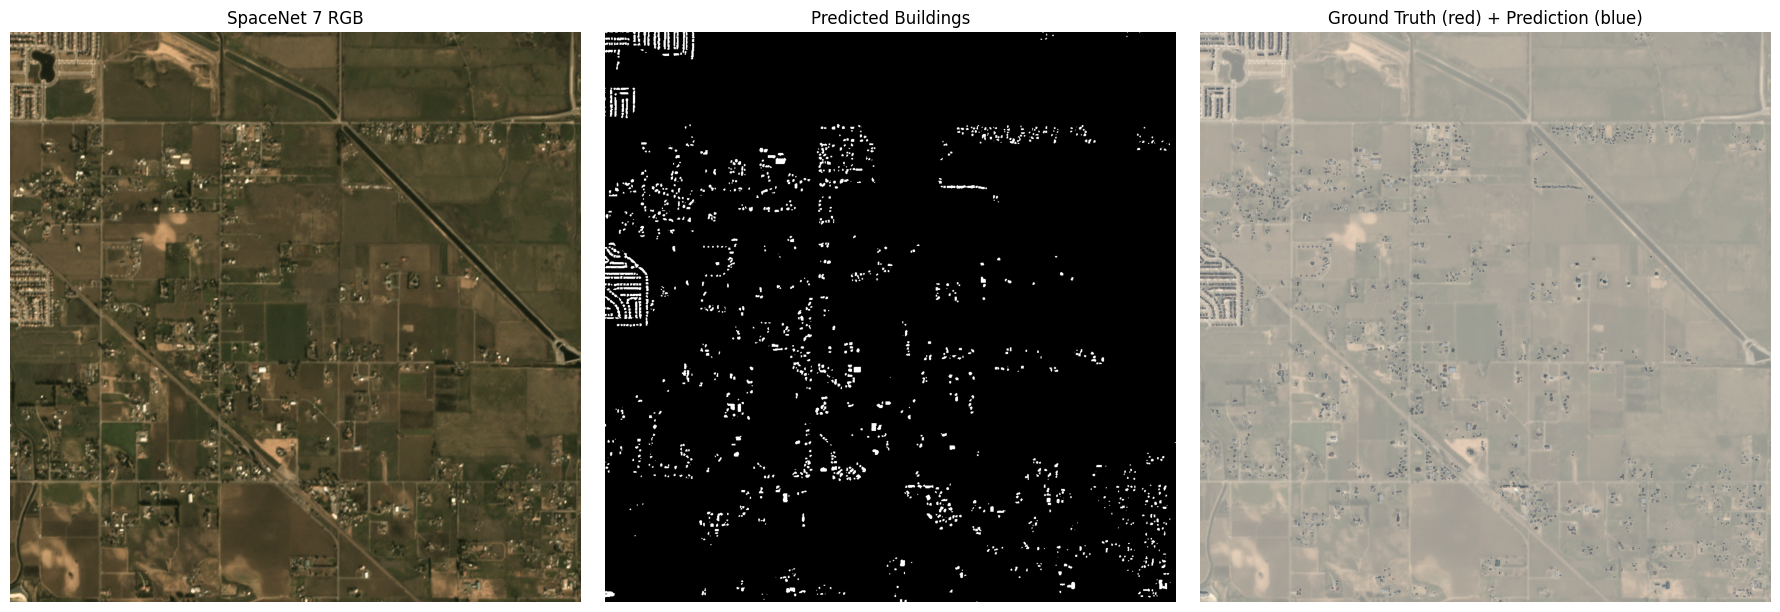

In [28]:
# ============================================================
# REAL SPACENET 7 BASELINE INFERENCE + FIRST METRICS
# No installs. No downloads.
# ============================================================

import os
import numpy as np
import torch
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.features import rasterize

from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images


# ============================================================
# 1. PATHS
# ============================================================

image_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/images/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif"
)

label_path = (
    "/content/sn7_real/train/"
    "L15-0331E-1257N_1327_3160_13/labels_match_pix/"
    "global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson"
)

assert os.path.exists(image_path), "Image missing"
assert os.path.exists(label_path), "Label missing"

print("✅ Image found")
print("✅ Label found")


# ============================================================
# 2. INSPECT IMAGE
# ============================================================

with rasterio.open(image_path) as src:
    height = src.height
    width = src.width
    raster_crs = src.crs
    raster_transform = src.transform
    rgb = src.read([1, 2, 3])

print()
print("Raster:", width, "x", height)
print("Bands :", rgb.shape[0])
print("CRS   :", raster_crs)


# ============================================================
# 3. OFFICIAL SPACE NET 7 INFERENCE AUGMENTATION
#    Drop 4th channel (index 3)
# ============================================================

inference_aug_dict = {
    "augmentations": {
        "DropChannel": {
            "idx": 3,
            "axis": 2
        }
    },
    "p": 1.0
}

aug = process_aug_dict(inference_aug_dict)

print("✅ Inference preprocessing ready")


# ============================================================
# 4. CREATE 512x512 INFERENCE TILER
# ============================================================

tiler = InferenceTiler(
    framework="torch",
    width=512,
    height=512,
    x_step=512,
    y_step=512,
    augmentations=aug
)

tiles, idx_refs, (src_h, src_w) = tiler(image_path)

print()
print("Tile tensor shape:", tiles.shape)
print("Number of tiles :", len(idx_refs))
print("Tile references :", idx_refs)


# ============================================================
# 5. MODEL CHECK
# ============================================================

device = next(model.parameters()).device

print()
print("Model device:", device)
print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

# tiles should be [N, 3, 512, 512]
assert tiles.shape[1:] == (3, 512, 512), tiles.shape

x = torch.from_numpy(tiles).float().to(device)


# ============================================================
# 6. REAL MODEL INFERENCE
# ============================================================

print("\n🔥 Running real SpaceNet 7 image through model...")

model.eval()

with torch.no_grad():
    logits = model(x)

logits = logits.detach().cpu().numpy()

print("Raw output shape:", logits.shape)


# ============================================================
# 7. STITCH TILE PREDICTIONS
# ============================================================

stitched_logits = stitch_images(
    logits,
    idx_refs=idx_refs,
    out_width=src_w,
    out_height=src_h,
    method="average",
    use_GPU=True
)

stitched_logits = np.squeeze(stitched_logits)

print("Stitched shape:", stitched_logits.shape)


# ============================================================
# 8. LOGITS -> PROBABILITY -> MASK
# ============================================================

prob = 1.0 / (1.0 + np.exp(-stitched_logits))

pred_mask = (prob >= 0.5).astype(np.uint8)

print()
print("Prediction statistics")
print("----------------------")
print("Probability min :", float(np.nanmin(prob)))
print("Probability max :", float(np.nanmax(prob)))
print("Probability mean:", float(np.nanmean(prob)))
print("Building pixels :", int(pred_mask.sum()))


# ============================================================
# 9. LOAD GROUND TRUTH
# ============================================================

gdf = gpd.read_file(label_path)

print()
print("Ground-truth polygons:", len(gdf))
print("Label CRS:", gdf.crs)
print("Raster CRS:", raster_crs)

# Reproject labels to raster CRS
gdf = gdf.to_crs(raster_crs)

# Remove invalid / missing geometries
gdf = gdf[gdf.geometry.notna()].copy()

gdf = gdf[gdf.geometry.is_valid].copy()


# ============================================================
# 10. RASTERIZE GROUND TRUTH
# ============================================================

gt_mask = rasterize(
    [(geom, 1) for geom in gdf.geometry],
    out_shape=(height, width),
    transform=raster_transform,
    fill=0,
    dtype=np.uint8
)

print("Ground-truth building pixels:", int(gt_mask.sum()))


# ============================================================
# 11. PIXEL METRICS
# ============================================================

pred = pred_mask.astype(bool)
gt = gt_mask.astype(bool)

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
iou = tp / (tp + fp + fn + 1e-9)

print()
print("=" * 60)
print("SPACE NET 7 REAL-IMAGE BASELINE")
print("=" * 60)
print(f"TP        : {tp:,}")
print(f"FP        : {fp:,}")
print(f"FN        : {fn:,}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 / Dice : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print("=" * 60)


# ============================================================
# 12. VISUALIZATION
# ============================================================

rgb_display = np.moveaxis(rgb, 0, -1).astype(np.float32) / 255.0
rgb_display = np.clip(rgb_display, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_display)
axes[0].set_title("SpaceNet 7 RGB")
axes[0].axis("off")

axes[1].imshow(pred_mask, cmap="gray")
axes[1].set_title("Predicted Buildings")
axes[1].axis("off")

axes[2].imshow(rgb_display)
axes[2].imshow(
    gt_mask,
    cmap="Reds",
    alpha=0.35
)
axes[2].imshow(
    pred_mask,
    cmap="Blues",
    alpha=0.30
)
axes[2].set_title("Ground Truth (red) + Prediction (blue)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# DEBUG: WHY DID GROUND TRUTH RASTERIZE TO ZERO?
# ============================================================

import rasterio
import geopandas as gpd
import numpy as np

from shapely.geometry import box

# ------------------------------------------------------------
# Load raster bounds
# ------------------------------------------------------------

with rasterio.open(image_path) as src:
    raster_bounds = src.bounds
    raster_crs = src.crs
    raster_shape = (src.height, src.width)

print("RASTER")
print("CRS   :", raster_crs)
print("Bounds:", raster_bounds)
print("Shape :", raster_shape)

# ------------------------------------------------------------
# Load labels
# ------------------------------------------------------------

gdf_raw = gpd.read_file(label_path)

print("\nLABELS BEFORE REPROJECTION")
print("CRS       :", gdf_raw.crs)
print("Count     :", len(gdf_raw))
print("Bounds    :", gdf_raw.total_bounds)
print("Geom types:")
print(gdf_raw.geometry.geom_type.value_counts())

print("\nValid geometries:", gdf_raw.geometry.is_valid.sum())
print("Empty geometries:", gdf_raw.geometry.is_empty.sum())
print("Null geometries :", gdf_raw.geometry.isna().sum())

# ------------------------------------------------------------
# Reproject
# ------------------------------------------------------------

gdf_proj = gdf_raw.to_crs(raster_crs)

print("\nLABELS AFTER REPROJECTION")
print("CRS    :", gdf_proj.crs)
print("Bounds :", gdf_proj.total_bounds)

# ------------------------------------------------------------
# Test bounding-box overlap
# ------------------------------------------------------------

raster_box = box(*raster_bounds)

overlap = gdf_proj.geometry.intersects(raster_box)

print("\nOVERLAP TEST")
print("Polygons intersecting raster:", int(overlap.sum()))
print("Polygons outside raster      :", int((~overlap).sum()))

# ------------------------------------------------------------
# Show a few transformed geometries
# ------------------------------------------------------------

print("\nFIRST 5 TRANSFORMED GEOMETRIES")

for i, geom in enumerate(gdf_proj.geometry.head(5)):
    print(
        i,
        "bounds=",
        geom.bounds,
        "area=",
        geom.area,
        "valid=",
        geom.is_valid,
    )

RASTER
CRS   : EPSG:3857
Bounds: BoundingBox(left=-13545864.404585794, bottom=4573996.549899891, right=-13540972.434776222, top=4578883.742395196)
Shape : (1023, 1024)

LABELS BEFORE REPROJECTION
CRS       : EPSG:4326
Count     : 1940
Bounds    : [-2.20989631e+00 -4.20225391e-01  1.02493378e+03  1.02246457e+03]
Geom types:
Polygon    1940
Name: count, dtype: int64

Valid geometries: 1940
Empty geometries: 0
Null geometries : 0

LABELS AFTER REPROJECTION
CRS    : PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["

/usr/local/lib/python3.13/dist-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/usr/local/lib/python3.13/dist-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/usr/local/lib/python3.13/dist-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/usr/local/lib/python3.13/dist-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)
/usr/local/lib/python3.13/dist-packages/shapely/measurement.py:50: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)


Raster: 1024 x 1023
Label polygons: 1940
Declared CRS : EPSG:4326
Pixel bounds : [-2.20989631e+00 -4.20225391e-01  1.02493378e+03  1.02246457e+03]

Pixel-space overlap:
Intersecting image: 1940
Outside image      : 0
Usable polygons: 1940

Ground-truth building pixels: 32097
Ground-truth coverage       : 3.064 %

SPACE NET 7 BASELINE — CORRECT GT ALIGNMENT
TP        : 22,041
FP        : 7,317
FN        : 10,056
TN        : 1,008,138
Precision : 0.7508
Recall    : 0.6867
F1 / Dice : 0.7173
IoU       : 0.5592


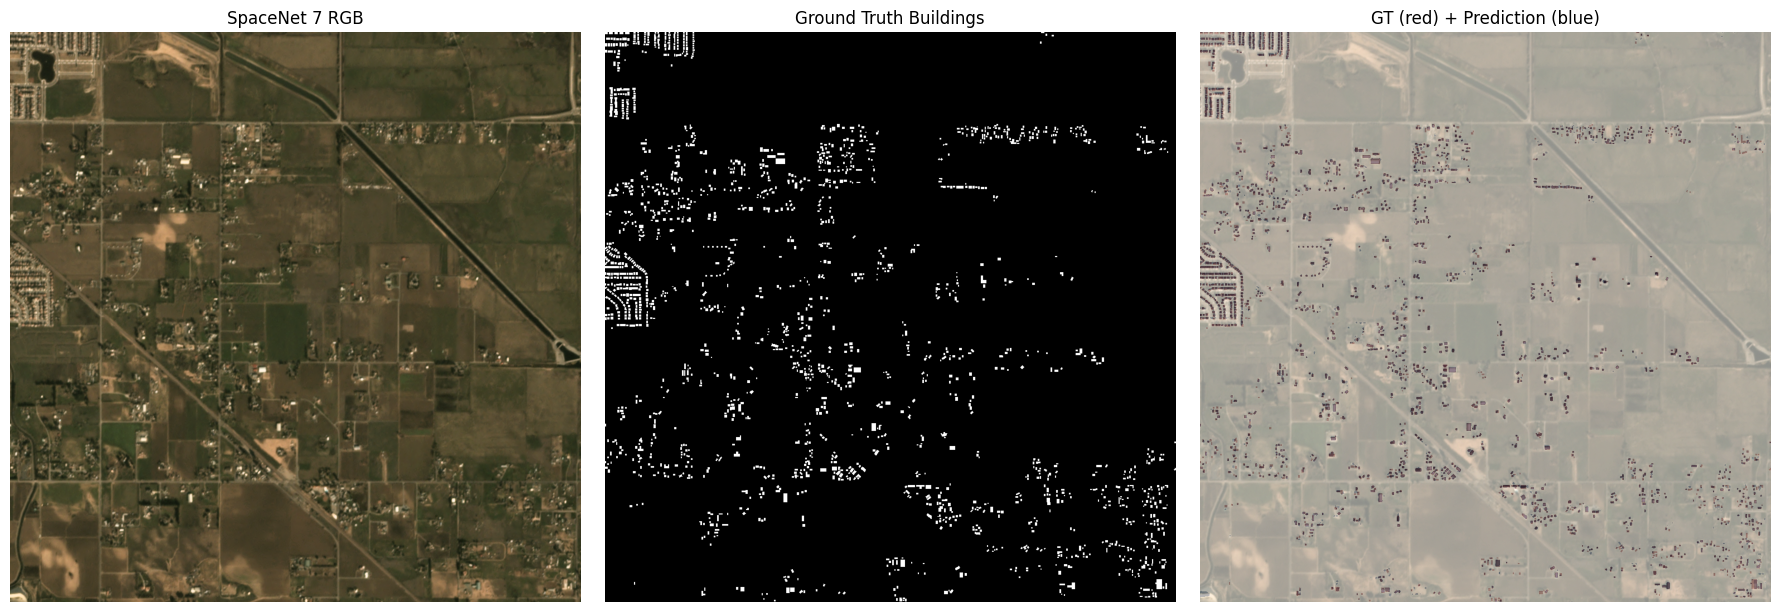

In [30]:
# ============================================================
# CORRECT SPACE NET 7 GROUND-TRUTH ALIGNMENT
# labels_match_pix = IMAGE PIXEL COORDINATES
# ============================================================

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from rasterio.features import rasterize
from affine import Affine

# ------------------------------------------------------------
# 1. Load raster metadata
# ------------------------------------------------------------

with rasterio.open(image_path) as src:
    height = src.height
    width = src.width
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

print("Raster:", width, "x", height)

# ------------------------------------------------------------
# 2. Load PIXEL-space labels
# ------------------------------------------------------------

gdf_pix = gpd.read_file(label_path)

print("Label polygons:", len(gdf_pix))
print("Declared CRS :", gdf_pix.crs)
print("Pixel bounds :", gdf_pix.total_bounds)

# IMPORTANT:
# DO NOT call to_crs() here.
#
# The bounds are already in image pixel coordinates.

# ------------------------------------------------------------
# 3. Check pixel-coordinate overlap
# ------------------------------------------------------------

pixel_extent = box(0, 0, width, height)

inside = gdf_pix.geometry.intersects(pixel_extent)

print()
print("Pixel-space overlap:")
print("Intersecting image:", int(inside.sum()))
print("Outside image      :", int((~inside).sum()))

# ------------------------------------------------------------
# 4. Clip polygons to image bounds
# ------------------------------------------------------------

gdf_pix = gdf_pix[gdf_pix.geometry.notna()].copy()

gdf_pix["geometry"] = gdf_pix.geometry.intersection(pixel_extent)

gdf_pix = gdf_pix[
    (~gdf_pix.geometry.is_empty) &
    (gdf_pix.geometry.notna())
].copy()

print("Usable polygons:", len(gdf_pix))

# ------------------------------------------------------------
# 5. Rasterize using IDENTITY transform
#
# Pixel coordinate convention:
# x = column
# y = row
#
# Identity keeps those coordinates directly aligned
# with the 1024 x 1023 image grid.
# ------------------------------------------------------------

gt_mask = rasterize(
    [(geom, 1) for geom in gdf_pix.geometry],
    out_shape=(height, width),
    transform=Affine.identity(),
    fill=0,
    dtype=np.uint8
)

print()
print("Ground-truth building pixels:", int(gt_mask.sum()))
print("Ground-truth coverage       :",
      round(100 * gt_mask.mean(), 3), "%")

# ------------------------------------------------------------
# 6. Compare with prediction already computed
# ------------------------------------------------------------

pred = pred_mask.astype(bool)
gt = gt_mask.astype(bool)

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
iou = tp / (tp + fp + fn + 1e-9)

print()
print("=" * 60)
print("SPACE NET 7 BASELINE — CORRECT GT ALIGNMENT")
print("=" * 60)
print(f"TP        : {tp:,}")
print(f"FP        : {fp:,}")
print(f"FN        : {fn:,}")
print(f"TN        : {tn:,}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 / Dice : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print("=" * 60)

# ------------------------------------------------------------
# 7. VISUAL CHECK
# ------------------------------------------------------------

rgb_display = rgb.astype(np.float32) / 255.0
rgb_display = np.clip(rgb_display, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_display)
axes[0].set_title("SpaceNet 7 RGB")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Ground Truth Buildings")
axes[1].axis("off")

axes[2].imshow(rgb_display)
axes[2].imshow(gt_mask, cmap="Reds", alpha=0.35)
axes[2].imshow(pred_mask, cmap="Blues", alpha=0.30)
axes[2].set_title("GT (red) + Prediction (blue)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# GROUNDTRUTH AI — 10 IMAGE BENCHMARK DATASET
# 5 AOIs x 2 months
# No pip installs. No archive download.
# ============================================================

import os
import urllib.request
from urllib.error import HTTPError, URLError

AOIS = [
    "L15-0331E-1257N_1327_3160_13",
    "L15-1204E-1204N_4819_3372_13",
    "L15-0457E-1135N_1831_3648_13",
    "L15-0506E-1204N_2027_3374_13",
    "L15-1848E-0793N_7394_5018_13",
]

MONTHS = [
    "2018_01",
    "2019_01",
]

BASE_URL = (
    "https://spacenet-dataset.s3.amazonaws.com/"
    "spacenet/SN7_buildings/train/"
)

ROOT = "/content/groundtruth_benchmark"
os.makedirs(ROOT, exist_ok=True)


def download_file(url, path):
    if os.path.exists(path):
        print("✅ Already exists:", os.path.basename(path))
        return True

    try:
        urllib.request.urlretrieve(url, path)
        print(
            "✅ Downloaded:",
            os.path.basename(path),
            f"({os.path.getsize(path)/(1024**2):.2f} MB)"
        )
        return True

    except (HTTPError, URLError, OSError) as e:
        print("❌ Failed:", url)
        print("   ", e)

        if os.path.exists(path):
            os.remove(path)

        return False


samples = []

for aoi in AOIS:
    for month in MONTHS:

        prefix = f"global_monthly_{month}_mosaic_{aoi}"

        image_url = (
            BASE_URL
            + f"{aoi}/images/{prefix}.tif"
        )

        label_url = (
            BASE_URL
            + f"{aoi}/labels_match_pix/"
            f"{prefix}_Buildings.geojson"
        )

        sample_dir = os.path.join(ROOT, aoi, month)
        image_dir = os.path.join(sample_dir, "images")
        label_dir = os.path.join(sample_dir, "labels")

        os.makedirs(image_dir, exist_ok=True)
        os.makedirs(label_dir, exist_ok=True)

        image_path = os.path.join(
            image_dir,
            f"{prefix}.tif"
        )

        label_path = os.path.join(
            label_dir,
            f"{prefix}_Buildings.geojson"
        )

        print(f"\n--- {aoi} | {month} ---")

        image_ok = download_file(image_url, image_path)
        label_ok = download_file(label_url, label_path)

        if image_ok and label_ok:
            samples.append({
                "aoi": aoi,
                "month": month,
                "image_path": image_path,
                "label_path": label_path,
            })

print("\n" + "=" * 70)
print("BENCHMARK DATASET READY")
print("=" * 70)
print("Successful samples:", len(samples))
print("=" * 70)

for s in samples:
    print(s["aoi"], "|", s["month"])


--- L15-0331E-1257N_1327_3160_13 | 2018_01 ---
✅ Downloaded: global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13.tif (4.00 MB)
✅ Downloaded: global_monthly_2018_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson (0.84 MB)

--- L15-0331E-1257N_1327_3160_13 | 2019_01 ---
✅ Downloaded: global_monthly_2019_01_mosaic_L15-0331E-1257N_1327_3160_13.tif (4.00 MB)
✅ Downloaded: global_monthly_2019_01_mosaic_L15-0331E-1257N_1327_3160_13_Buildings.geojson (0.90 MB)

--- L15-1204E-1204N_4819_3372_13 | 2018_01 ---
✅ Downloaded: global_monthly_2018_01_mosaic_L15-1204E-1204N_4819_3372_13.tif (4.00 MB)
✅ Downloaded: global_monthly_2018_01_mosaic_L15-1204E-1204N_4819_3372_13_Buildings.geojson (0.49 MB)

--- L15-1204E-1204N_4819_3372_13 | 2019_01 ---
✅ Downloaded: global_monthly_2019_01_mosaic_L15-1204E-1204N_4819_3372_13.tif (4.00 MB)
✅ Downloaded: global_monthly_2019_01_mosaic_L15-1204E-1204N_4819_3372_13_Buildings.geojson (0.56 MB)

--- L15-0457E-1135N_1831_3648_13 | 2018_01 ---
✅ Downlo

In [32]:
# ============================================================
# GROUNDTRUTH AI — 10 IMAGE BASELINE BENCHMARK
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch
import rasterio
import geopandas as gpd

from rasterio.features import rasterize
from shapely.geometry import box
from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model.eval()
device = next(model.parameters()).device

print("Model device:", device)


# ------------------------------------------------------------
# Same preprocessing used for our current baseline
# ------------------------------------------------------------

inference_aug_dict = {
    "augmentations": {
        "DropChannel": {
            "idx": 3,
            "axis": 2
        }
    },
    "p": 1.0
}

aug = process_aug_dict(inference_aug_dict)


# ------------------------------------------------------------
# Evaluation function
# ------------------------------------------------------------

def evaluate_sample(sample):

    image_path = sample["image_path"]
    label_path = sample["label_path"]

    # -----------------------------
    # Raster metadata
    # -----------------------------

    with rasterio.open(image_path) as src:
        height = src.height
        width = src.width

    # -----------------------------
    # Tile image
    # -----------------------------

    tiler = InferenceTiler(
        framework="torch",
        width=512,
        height=512,
        x_step=512,
        y_step=512,
        augmentations=aug
    )

    tiles, idx_refs, (src_h, src_w) = tiler(image_path)

    # -----------------------------
    # Model inference
    # -----------------------------

    x = torch.from_numpy(tiles).float().to(device)

    with torch.no_grad():
        logits = model(x)

    logits = logits.detach().cpu().numpy()

    del x, tiles
    torch.cuda.empty_cache()

    # -----------------------------
    # Stitch
    # -----------------------------

    stitched = stitch_images(
        logits,
        idx_refs=idx_refs,
        out_width=src_w,
        out_height=src_h,
        method="average",
        use_GPU=True
    )

    stitched = np.squeeze(stitched)

    # -----------------------------
    # Probability + mask
    # -----------------------------

    probability = 1.0 / (1.0 + np.exp(-stitched))
    pred_mask = probability >= 0.5

    del logits, stitched
    torch.cuda.empty_cache()

    # -----------------------------
    # Ground truth
    #
    # IMPORTANT:
    # labels_match_pix uses pixel coordinates.
    # Do NOT reproject it.
    # -----------------------------

    gdf = gpd.read_file(label_path)

    pixel_extent = box(0, 0, width, height)

    gdf = gdf[gdf.geometry.notna()].copy()

    gdf["geometry"] = gdf.geometry.intersection(pixel_extent)

    gdf = gdf[
        (~gdf.geometry.is_empty) &
        (gdf.geometry.notna())
    ].copy()

    gt_mask = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(height, width),
        transform=rasterio.Affine.identity(),
        fill=0,
        dtype=np.uint8
    ).astype(bool)

    # -----------------------------
    # Metrics
    # -----------------------------

    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (
        precision + recall + 1e-9
    )
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        "aoi": sample["aoi"],
        "month": sample["month"],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "gt_pixels": int(gt_mask.sum()),
        "pred_pixels": int(pred_mask.sum()),
    }


# ------------------------------------------------------------
# Run benchmark
# ------------------------------------------------------------

results = []

for i, sample in enumerate(samples, start=1):

    print()
    print("=" * 70)
    print(f"[{i}/{len(samples)}] {sample['aoi']} | {sample['month']}")
    print("=" * 70)

    try:
        result = evaluate_sample(sample)
        results.append(result)

        print(
            f"Precision: {result['precision']:.4f} | "
            f"Recall: {result['recall']:.4f} | "
            f"F1: {result['f1']:.4f} | "
            f"IoU: {result['iou']:.4f}"
        )

    except Exception as e:
        print("❌ FAILED:", repr(e))


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "f1",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 90)
print("GROUNDTRUTH AI — BASELINE BENCHMARK")
print("=" * 90)

display(
    results_df[
        [
            "aoi",
            "month",
            "precision",
            "recall",
            "f1",
            "iou"
        ]
    ]
)

# ------------------------------------------------------------
# Aggregate
# ------------------------------------------------------------

print("\nAGGREGATE RESULTS")
print("-" * 50)

for metric in ["precision", "recall", "f1", "iou"]:
    print(
        f"{metric.capitalize():10s}: "
        f"{results_df[metric].mean():.4f} ± "
        f"{results_df[metric].std(ddof=1):.4f}"
    )

print("\nSuccessful samples:", len(results_df))

# Save results
csv_path = "/content/groundtruth_benchmark_results.csv"
results_df.to_csv(csv_path, index=False)

print("\nSaved:", csv_path)

Model device: cuda:0

[1/10] L15-0331E-1257N_1327_3160_13 | 2018_01
Precision: 0.7508 | Recall: 0.6867 | F1: 0.7173 | IoU: 0.5592

[2/10] L15-0331E-1257N_1327_3160_13 | 2019_01
Precision: 0.7080 | Recall: 0.6430 | F1: 0.6739 | IoU: 0.5082

[3/10] L15-1204E-1204N_4819_3372_13 | 2018_01
Precision: 0.8891 | Recall: 0.9094 | F1: 0.8991 | IoU: 0.8167

[4/10] L15-1204E-1204N_4819_3372_13 | 2019_01
Precision: 0.8955 | Recall: 0.9077 | F1: 0.9016 | IoU: 0.8208

[5/10] L15-0457E-1135N_1831_3648_13 | 2018_01
Precision: 0.7516 | Recall: 0.7319 | F1: 0.7416 | IoU: 0.5893

[6/10] L15-0457E-1135N_1831_3648_13 | 2019_01
Precision: 0.7366 | Recall: 0.7225 | F1: 0.7295 | IoU: 0.5742

[7/10] L15-0506E-1204N_2027_3374_13 | 2018_01
Precision: 0.6425 | Recall: 0.5424 | F1: 0.5882 | IoU: 0.4167

[8/10] L15-0506E-1204N_2027_3374_13 | 2019_01
Precision: 0.6443 | Recall: 0.5141 | F1: 0.5719 | IoU: 0.4004

[9/10] L15-1848E-0793N_7394_5018_13 | 2018_01
Precision: 0.7090 | Recall: 0.7090 | F1: 0.7090 | IoU: 0.549

,aoi,month,precision,recall,f1,iou
0,L15-1204E-1204N_4819_3372_13,2019_01,0.895531,0.907672,0.901561,0.820766
1,L15-1204E-1204N_4819_3372_13,2018_01,0.889066,0.909351,0.899094,0.816685
2,L15-0457E-1135N_1831_3648_13,2018_01,0.751564,0.731923,0.741614,0.589337
3,L15-0457E-1135N_1831_3648_13,2019_01,0.736614,0.722501,0.729489,0.574170
4,L15-0331E-1257N_1327_3160_13,2018_01,0.750766,0.686700,0.717305,0.559218
5,L15-1848E-0793N_7394_5018_13,2018_01,0.709029,0.709029,0.709029,0.549221
6,L15-0331E-1257N_1327_3160_13,2019_01,0.707970,0.642988,0.673916,0.508200
7,L15-1848E-0793N_7394_5018_13,2019_01,0.649653,0.690160,0.669294,0.502962
8,L15-0506E-1204N_2027_3374_13,2018_01,0.642494,0.542418,0.588230,0.416661
9,L15-0506E-1204N_2027_3374_13,2019_01,0.644258,0.514074,0.571850,0.400414



AGGREGATE RESULTS
--------------------------------------------------
Precision : 0.7377 ± 0.0916
Recall    : 0.7057 ± 0.1296
F1        : 0.7201 ± 0.1104
Iou       : 0.5738 ± 0.1434

Successful samples: 10

Saved: /content/groundtruth_benchmark_results.csv


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
import os
import shutil

backup_dir = "/content/drive/MyDrive/GroundTruth_AI_backup"
os.makedirs(backup_dir, exist_ok=True)

# Save benchmark results
if os.path.exists("/content/groundtruth_benchmark_results.csv"):
    shutil.copy2(
        "/content/groundtruth_benchmark_results.csv",
        backup_dir
    )

# Save the model checkpoint
ckpt = "/content/CosmiQ_SN7_Baseline/models/sn7_baseline/xdxd_final.pth"

if os.path.exists(ckpt):
    shutil.copy2(
        ckpt,
        os.path.join(backup_dir, "xdxd_final.pth")
    )

print("✅ Important results/checkpoint backed up to Drive")

✅ Important results/checkpoint backed up to Drive


In [1]:
# ============================================================
# GROUNDTRUTH AI — RUNTIME RECOVERY 1/4
# Restore the exact working Solaris environment
# ============================================================

import sys
import subprocess

print("Python:", sys.version)

# ------------------------------------------------------------
# 1. Pip 24.0 is required for Solaris 0.4.0's old metadata
# ------------------------------------------------------------

subprocess.run([
    sys.executable, "-m", "pip",
    "install", "--quiet", "--force-reinstall", "pip==24.0"
], check=True)

print("✅ pip 24.0 restored")

# ------------------------------------------------------------
# 2. Install exact legacy packages
# ------------------------------------------------------------

packages = [
    "solaris==0.4.0",
    "albumentations==0.4.6",
    "imgaug==0.4.0",
    "fiona==1.10.1",
]

for package in packages:
    print("Installing:", package)

    subprocess.run([
        sys.executable, "-m", "pip",
        "install", "--quiet",
        "--no-deps",
        "--force-reinstall",
        package
    ], check=True)

print("✅ Required packages restored")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
✅ pip 24.0 restored
Installing: solaris==0.4.0
Installing: albumentations==0.4.6
Installing: imgaug==0.4.0
Installing: fiona==1.10.1
✅ Required packages restored


In [2]:
# ============================================================
# GROUNDTRUTH AI — RUNTIME RECOVERY 2/4
# Solaris 0.4.0 compatibility layer
# ============================================================

import sys
import importlib
import numpy as np
import tensorflow as tf
import keras

# ------------------------------------------------------------
# NumPy -> imgaug
# ------------------------------------------------------------

if not hasattr(np, "sctypes"):
    np.sctypes = {
        "int": [np.int8, np.int16, np.int32, np.int64],
        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],
        "float": [np.float16, np.float32, np.float64],
        "complex": [np.complex64, np.complex128],
        "others": [np.bool_, np.bytes_, np.str_],
    }

# ------------------------------------------------------------
# Keras
# ------------------------------------------------------------

tf_metrics = tf.keras.metrics
tf_losses = tf.keras.losses

try:
    internal_metrics = importlib.import_module(
        "keras._tf_keras.keras.metrics"
    )
except Exception:
    internal_metrics = tf_metrics

try:
    internal_losses = importlib.import_module(
        "keras._tf_keras.keras.losses"
    )
except Exception:
    internal_losses = tf_losses

keras_metrics = keras.metrics
keras_losses = keras.losses

metric_modules = [
    keras_metrics,
    tf_metrics,
    internal_metrics,
]

loss_modules = [
    keras_losses,
    tf_losses,
    internal_losses,
]


def mae(y_true, y_pred):
    return tf.reduce_mean(
        tf.abs(
            tf.cast(y_pred, tf.float32)
            - tf.cast(y_true, tf.float32)
        ),
        axis=-1
    )


def mse(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(
            tf.cast(y_pred, tf.float32)
            - tf.cast(y_true, tf.float32)
        ),
        axis=-1
    )


def msle(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    return tf.reduce_mean(
        tf.square(
            tf.math.log1p(tf.maximum(y_pred, 0.0))
            - tf.math.log1p(tf.maximum(y_true, 0.0))
        ),
        axis=-1
    )


def cosine(y_true, y_pred):
    y_true = tf.math.l2_normalize(
        tf.cast(y_true, tf.float32), axis=-1
    )
    y_pred = tf.math.l2_normalize(
        tf.cast(y_pred, tf.float32), axis=-1
    )

    return -tf.reduce_sum(y_true * y_pred, axis=-1)


def hinge(y_true, y_pred):
    return tf.reduce_mean(
        tf.maximum(
            1.0 - tf.cast(y_true, tf.float32)
            * tf.cast(y_pred, tf.float32),
            0.0
        ),
        axis=-1
    )


def squared_hinge(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(
            tf.maximum(
                1.0 - tf.cast(y_true, tf.float32)
                * tf.cast(y_pred, tf.float32),
                0.0
            )
        ),
        axis=-1
    )


def kld(y_true, y_pred):
    y_true = tf.clip_by_value(
        tf.cast(y_true, tf.float32), 1e-7, 1.0
    )
    y_pred = tf.clip_by_value(
        tf.cast(y_pred, tf.float32), 1e-7, 1.0
    )

    return tf.reduce_sum(
        y_true * tf.math.log(y_true / y_pred),
        axis=-1
    )


for m in metric_modules:
    m.mean_absolute_error = mae
    m.mean_squared_error = mse
    m.mean_squared_logarithmic_error = msle
    m.cosine_proximity = cosine
    m.hinge = hinge

for l in loss_modules:
    l.mean_absolute_error = mae
    l.mae = mae
    l.mean_squared_error = mse
    l.mse = mse
    l.mean_squared_logarithmic_error = msle
    l.msle = msle
    l.cosine = cosine
    l.cosine_proximity = cosine
    l.hinge = hinge
    l.squared_hinge = squared_hinge
    l.kullback_leibler_divergence = kld
    l.kld = kld

# ------------------------------------------------------------
# GDAL
# ------------------------------------------------------------

from osgeo import gdal, gdalconst, ogr, osr

sys.modules["gdal"] = gdal
sys.modules["gdalconst"] = gdalconst
sys.modules["ogr"] = ogr
sys.modules["osr"] = osr

# ------------------------------------------------------------
# Shapely
# ------------------------------------------------------------

import shapely
import shapely.ops

if not hasattr(shapely.ops, "cascaded_union"):
    shapely.ops.cascaded_union = shapely.ops.unary_union

# ------------------------------------------------------------
# Clear partial imports
# ------------------------------------------------------------

for name in list(sys.modules):
    if name == "solaris" or name.startswith("solaris."):
        del sys.modules[name]

# ------------------------------------------------------------
# Test
# ------------------------------------------------------------

import solaris
from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images

print()
print("=" * 60)
print("🎉 SOLARIS RESTORED")
print("=" * 60)
print("Solaris:", solaris.__version__)
print("✅ InferenceTiler")
print("✅ process_aug_dict")
print("✅ stitch_images")
print("=" * 60)


🎉 SOLARIS RESTORED
Solaris: 0.4.0
✅ InferenceTiler
✅ process_aug_dict
✅ stitch_images


In [3]:
# ============================================================
# GROUNDTRUTH AI — RUNTIME RECOVERY 3/4
# Restore checkpoint + 10 benchmark scenes
# No pip installs
# ============================================================

import os
import subprocess
import urllib.request

# ------------------------------------------------------------
# 1. Restore official repository + checkpoint
# ------------------------------------------------------------

repo = "/content/CosmiQ_SN7_Baseline"
model_dir = f"{repo}/models/sn7_baseline"
ckpt = f"{model_dir}/xdxd_final.pth"

if not os.path.exists(repo):
    print("Cloning official SpaceNet 7 baseline...")
    subprocess.run([
        "git", "clone",
        "https://github.com/CosmiQ/CosmiQ_SN7_Baseline.git",
        repo
    ], check=True)
    print("✅ Repository cloned")
else:
    print("✅ Repository already exists")

if not os.path.exists(ckpt):
    aa = f"{model_dir}/weight_split/aa"
    ab = f"{model_dir}/weight_split/ab"

    print("Checkpoint chunks:")
    print("aa:", os.path.exists(aa))
    print("ab:", os.path.exists(ab))

    if not (os.path.exists(aa) and os.path.exists(ab)):
        raise FileNotFoundError(
            "Official checkpoint chunks were not found."
        )

    print("Reconstructing checkpoint...")

    with open(ckpt, "wb") as out:
        with open(aa, "rb") as f:
            out.write(f.read())
        with open(ab, "rb") as f:
            out.write(f.read())

    print("✅ Checkpoint reconstructed")
else:
    print("✅ Checkpoint already exists")

print(
    "Checkpoint size:",
    round(os.path.getsize(ckpt) / (1024**2), 2),
    "MB"
)


# ------------------------------------------------------------
# 2. Restore our 10 benchmark scenes
# ------------------------------------------------------------

AOIS = [
    "L15-0331E-1257N_1327_3160_13",
    "L15-1204E-1204N_4819_3372_13",
    "L15-0457E-1135N_1831_3648_13",
    "L15-0506E-1204N_2027_3374_13",
    "L15-1848E-0793N_7394_5018_13",
]

MONTHS = [
    "2018_01",
    "2019_01",
]

BASE_URL = (
    "https://spacenet-dataset.s3.amazonaws.com/"
    "spacenet/SN7_buildings/train/"
)

ROOT = "/content/groundtruth_benchmark"
os.makedirs(ROOT, exist_ok=True)

samples = []


def download(url, path):
    if os.path.exists(path):
        return True

    try:
        urllib.request.urlretrieve(url, path)
        return True
    except Exception as e:
        print("\n❌ Download failed:")
        print(url)
        print("Error:", repr(e))

        if os.path.exists(path):
            os.remove(path)

        return False


for aoi in AOIS:
    for month in MONTHS:

        prefix = f"global_monthly_{month}_mosaic_{aoi}"

        image_url = (
            BASE_URL
            + f"{aoi}/images/{prefix}.tif"
        )

        label_url = (
            BASE_URL
            + f"{aoi}/labels_match_pix/"
            f"{prefix}_Buildings.geojson"
        )

        sample_dir = os.path.join(ROOT, aoi, month)

        image_dir = os.path.join(sample_dir, "images")
        label_dir = os.path.join(sample_dir, "labels")

        os.makedirs(image_dir, exist_ok=True)
        os.makedirs(label_dir, exist_ok=True)

        image_path = os.path.join(
            image_dir,
            f"{prefix}.tif"
        )

        label_path = os.path.join(
            label_dir,
            f"{prefix}_Buildings.geojson"
        )

        print(f"\n[{aoi} | {month}]")

        image_ok = download(image_url, image_path)
        label_ok = download(label_url, label_path)

        if image_ok and label_ok:
            samples.append({
                "aoi": aoi,
                "month": month,
                "image_path": image_path,
                "label_path": label_path,
            })
            print("✅ Ready")
        else:
            print("❌ Incomplete")


print("\n" + "=" * 70)
print("RECOVERY DATA CHECK")
print("=" * 70)
print("Successful scenes:", len(samples))
print("Expected scenes  :", 10)
print("=" * 70)

Cloning official SpaceNet 7 baseline...
✅ Repository cloned
Checkpoint chunks:
aa: True
ab: True
Reconstructing checkpoint...
✅ Checkpoint reconstructed
Checkpoint size: 111.81 MB

[L15-0331E-1257N_1327_3160_13 | 2018_01]
✅ Ready

[L15-0331E-1257N_1327_3160_13 | 2019_01]
✅ Ready

[L15-1204E-1204N_4819_3372_13 | 2018_01]
✅ Ready

[L15-1204E-1204N_4819_3372_13 | 2019_01]
✅ Ready

[L15-0457E-1135N_1831_3648_13 | 2018_01]
✅ Ready

[L15-0457E-1135N_1831_3648_13 | 2019_01]
✅ Ready

[L15-0506E-1204N_2027_3374_13 | 2018_01]
✅ Ready

[L15-0506E-1204N_2027_3374_13 | 2019_01]
✅ Ready

[L15-1848E-0793N_7394_5018_13 | 2018_01]
✅ Ready

[L15-1848E-0793N_7394_5018_13 | 2019_01]
✅ Ready

RECOVERY DATA CHECK
Successful scenes: 10
Expected scenes  : 10


In [4]:
# ============================================================
# GROUNDTRUTH AI — RUNTIME RECOVERY 4/4
# Reload model on T4
# ============================================================

import torch
from solaris.nets.model_io import get_model

ckpt_path = (
    "/content/CosmiQ_SN7_Baseline/"
    "models/sn7_baseline/xdxd_final.pth"
)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = get_model(
    model_name="xdxd_spacenet4",
    framework="torch",
    model_path=ckpt_path,
    pretrained=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)
model.eval()

params = sum(p.numel() for p in model.parameters())

print("\n" + "=" * 60)
print("✅ MODEL RESTORED")
print("=" * 60)
print("Device     :", device)
print("Parameters :", f"{params:,}")
print("=" * 60)

CUDA available: True
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.9MB/s]



✅ MODEL RESTORED
Device     : cuda
Parameters : 29,306,465


In [5]:
# ============================================================
# GROUNDTRUTH AI — RESTORE MODEL
# ============================================================

import torch
from solaris.nets.model_io import get_model

ckpt_path = (
    "/content/CosmiQ_SN7_Baseline/"
    "models/sn7_baseline/xdxd_final.pth"
)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nLoading XDXD SpaceNet baseline...")

model = get_model(
    model_name="xdxd_spacenet4",
    framework="torch",
    model_path=ckpt_path,
    pretrained=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)
model.eval()

params = sum(p.numel() for p in model.parameters())

print("\n" + "=" * 60)
print("✅ MODEL RESTORED")
print("=" * 60)
print("Device     :", device)
print("Parameters :", f"{params:,}")
print("=" * 60)

CUDA available: True
GPU: Tesla T4

Loading XDXD SpaceNet baseline...

✅ MODEL RESTORED
Device     : cuda
Parameters : 29,306,465


In [6]:
# ============================================================
# GROUNDTRUTH AI — BEST / TYPICAL / HARD CASE ANALYSIS
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from rasterio.features import rasterize
from solaris.nets.datagen import InferenceTiler
from solaris.nets.transform import process_aug_dict
from solaris.raster.image import stitch_images


# ============================================================
# 1. SELECT REPRESENTATIVE CASES
# ============================================================

TARGETS = {
    "BEST": (
        "L15-1204E-1204N_4819_3372_13",
        "2019_01"
    ),

    "TYPICAL": (
        "L15-0457E-1135N_1831_3648_13",
        "2018_01"
    ),

    "HARD": (
        "L15-0506E-1204N_2027_3374_13",
        "2019_01"
    ),
}


def find_sample(aoi, month):
    for s in samples:
        if s["aoi"] == aoi and s["month"] == month:
            return s
    raise FileNotFoundError(
        f"Could not find benchmark sample: {aoi} | {month}"
    )


# ============================================================
# 2. INFERENCE PREPROCESSING
# ============================================================

inference_aug_dict = {
    "augmentations": {
        "DropChannel": {
            "idx": 3,
            "axis": 2
        }
    },
    "p": 1.0
}

aug = process_aug_dict(inference_aug_dict)

model.eval()
device = next(model.parameters()).device

print("Model device:", device)


# ============================================================
# 3. SINGLE-SCENE ANALYSIS FUNCTION
# ============================================================

def analyze_scene(sample):

    image_path = sample["image_path"]
    label_path = sample["label_path"]

    # --------------------------------------------------------
    # Raster
    # --------------------------------------------------------

    with rasterio.open(image_path) as src:

        height = src.height
        width = src.width

        rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

    rgb_display = rgb.astype(np.float32) / 255.0
    rgb_display = np.clip(rgb_display, 0, 1)

    # --------------------------------------------------------
    # Tile + inference
    # --------------------------------------------------------

    tiler = InferenceTiler(
        framework="torch",
        width=512,
        height=512,
        x_step=512,
        y_step=512,
        augmentations=aug
    )

    tiles, idx_refs, (src_h, src_w) = tiler(image_path)

    x = torch.from_numpy(tiles).float().to(device)

    with torch.no_grad():
        logits = model(x)

    logits = logits.detach().cpu().numpy()

    del x, tiles
    torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Stitch
    # --------------------------------------------------------

    stitched = stitch_images(
        logits,
        idx_refs=idx_refs,
        out_width=src_w,
        out_height=src_h,
        method="average",
        use_GPU=True
    )

    stitched = np.squeeze(stitched)

    # Stable sigmoid
    clipped = np.clip(stitched, -50, 50)

    probability = 1.0 / (1.0 + np.exp(-clipped))

    pred_mask = probability >= 0.5

    del logits, stitched
    torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    gdf = gpd.read_file(label_path)

    # labels_match_pix are already in pixel coordinates
    pixel_extent = box(0, 0, width, height)

    gdf = gdf[gdf.geometry.notna()].copy()

    gdf["geometry"] = gdf.geometry.intersection(pixel_extent)

    gdf = gdf[
        (~gdf.geometry.is_empty) &
        (gdf.geometry.notna())
    ].copy()

    gt_mask = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(height, width),
        transform=rasterio.Affine.identity(),
        fill=0,
        dtype=np.uint8
    ).astype(bool)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    tp = np.logical_and(pred_mask, gt_mask)
    fp = np.logical_and(pred_mask, ~gt_mask)
    fn = np.logical_and(~pred_mask, gt_mask)

    tp_count = int(tp.sum())
    fp_count = int(fp.sum())
    fn_count = int(fn.sum())

    precision = tp_count / (tp_count + fp_count + 1e-9)
    recall = tp_count / (tp_count + fn_count + 1e-9)
    f1 = 2 * precision * recall / (
        precision + recall + 1e-9
    )
    iou = tp_count / (
        tp_count + fp_count + fn_count + 1e-9
    )

    return {
        "rgb": rgb_display,
        "gt": gt_mask,
        "pred": pred_mask,
        "prob": probability,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "tp_count": tp_count,
        "fp_count": fp_count,
        "fn_count": fn_count,
    }


# ============================================================
# 4. RUN THE THREE CASES
# ============================================================

os.makedirs(
    "/content/groundtruth_demo",
    exist_ok=True
)

analysis_results = {}

for case_name, (aoi, month) in TARGETS.items():

    print()
    print("=" * 70)
    print(case_name)
    print(aoi, "|", month)
    print("=" * 70)

    sample = find_sample(aoi, month)

    result = analyze_scene(sample)

    analysis_results[case_name] = result

    print(
        f"Precision: {result['precision']:.4f}"
    )
    print(
        f"Recall   : {result['recall']:.4f}"
    )
    print(
        f"F1       : {result['f1']:.4f}"
    )
    print(
        f"IoU      : {result['iou']:.4f}"
    )


# ============================================================
# 5. CREATE VISUALS
# ============================================================

for case_name, result in analysis_results.items():

    rgb = result["rgb"]
    gt = result["gt"]
    pred = result["pred"]
    prob = result["prob"]

    tp = result["tp"]
    fp = result["fp"]
    fn = result["fn"]

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(25, 5)
    )

    # --------------------------------------------------------
    # RGB
    # --------------------------------------------------------

    axes[0].imshow(rgb)
    axes[0].set_title("1. Satellite RGB")
    axes[0].axis("off")

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    axes[1].imshow(rgb)
    axes[1].imshow(
        gt,
        alpha=0.45
    )
    axes[1].set_title("2. Ground Truth")
    axes[1].axis("off")

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    axes[2].imshow(rgb)
    axes[2].imshow(
        pred,
        alpha=0.45
    )
    axes[2].set_title(
        f"3. AI Prediction\nF1={result['f1']:.3f}"
    )
    axes[2].axis("off")

    # --------------------------------------------------------
    # Error map
    #
    # TP = green
    # FP = red
    # FN = blue
    # --------------------------------------------------------

    error_map = np.zeros(
        (*pred.shape, 3),
        dtype=np.float32
    )

    error_map[tp] = [0.0, 1.0, 0.0]
    error_map[fp] = [1.0, 0.0, 0.0]
    error_map[fn] = [0.0, 0.3, 1.0]

    axes[3].imshow(error_map)
    axes[3].set_title(
        "4. Error Map\n"
        "TP=Green  FP=Red  FN=Blue"
    )
    axes[3].axis("off")

    # --------------------------------------------------------
    # Confidence
    # --------------------------------------------------------

    im = axes[4].imshow(
        prob,
        vmin=0,
        vmax=1,
        cmap="viridis"
    )

    axes[4].set_title(
        "5. AI Confidence"
    )
    axes[4].axis("off")

    plt.colorbar(
        im,
        ax=axes[4],
        fraction=0.046,
        pad=0.04
    )

    fig.suptitle(
        f"GroundTruth AI — {case_name}",
        fontsize=16
    )

    plt.tight_layout()

    save_path = (
        f"/content/groundtruth_demo/"
        f"{case_name.lower()}_analysis.png"
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", save_path)


# ============================================================
# 6. FINAL SUMMARY TABLE
# ============================================================

summary = []

for case_name, result in analysis_results.items():

    summary.append({
        "case": case_name,
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"],
        "iou": result["iou"],
        "TP_pixels": result["tp_count"],
        "FP_pixels": result["fp_count"],
        "FN_pixels": result["fn_count"],
    })

demo_df = pd.DataFrame(summary)

print()
print("=" * 80)
print("GROUNDTRUTH AI — DEMO CASE SUMMARY")
print("=" * 80)

display(demo_df)

demo_csv = (
    "/content/groundtruth_demo/"
    "demo_case_metrics.csv"
)

demo_df.to_csv(
    demo_csv,
    index=False
)

print("Saved:", demo_csv)

Output hidden; open in https://colab.research.google.com to view.

In [7]:
%cd /content/GroundTruth-AI

!git remote -v

[Errno 2] No such file or directory: '/content/GroundTruth-AI'
/content
fatal: not a git repository (or any of the parent directories): .git


In [8]:
!git remote add origin https://github.com/rithvik-30/Geeksx.git

fatal: not a git repository (or any of the parent directories): .git


In [9]:
!mkdir -p /content/GroundTruth-AI/notebooks
!mkdir -p /content/GroundTruth-AI/results

%cd /content/GroundTruth-AI
!git init -b main

/content/GroundTruth-AI
Initialized empty Git repository in /content/GroundTruth-AI/.git/


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import glob
import os

notebooks = glob.glob(
    "/content/drive/MyDrive/**/*.ipynb",
    recursive=True
)

notebooks = sorted(
    notebooks,
    key=os.path.getmtime,
    reverse=True
)

print("Recent notebooks:")
for p in notebooks[:15]:
    print(p)

Recent notebooks:
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb


In [ ]:
import os
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb"

print("Exists:", os.path.exists(notebook_path))
print("Size:", round(os.path.getsize(notebook_path) / 1024, 1), "KB")

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

code = "\n".join(
    cell.get("source", [])
    if isinstance(cell.get("source", []), str)
    else "".join(cell.get("source", []))
    for cell in nb.get("cells", [])
    if cell.get("cell_type") == "code"
)

checks = {
    "10-image benchmark": "10 IMAGE BENCHMARK" in code,
    "Best/Typical/Hard": "BEST / TYPICAL / HARD" in code,
    "SpaceNet baseline": "xdxd_spacenet4" in code,
    "OSM direction": "OpenStreetMap" in code or "OSM" in code,
}

print("\nNotebook checks:")
for name, found in checks.items():
    print(f"{'✅' if found else '❌'} {name}")

Exists: True
Size: 3551.3 KB
